### Tutorial: how to use `pangeo-fish`


**Overview.**

This Jupyter notebook demonstrates how to use `pangeo-fish`.

Specifically, we will fit the geolocation on the data from the study conducted by M. Gonze et al. titled "Combining acoustic telemetry with archival tagging to investigate the spatial dynamics of the understudied pollack *Pollachius pollachius*", accepted for publication in the Journal of Fish Biology.

We will use the biologging tag "A19124", which was attached to pollack fish.

As for the reference Earth Observation (EO) data, we consider the European Union Copernicus Marine Service Information (CMEMS) product "NORTHWESTSHELF_ANALYSIS_FORECAST_PHY_004_013".

_NB: In addition to the Data Storage Tag (DST), the biologging data includes **teledetection by acoustic signals**, as well as the release and recapture/death information of the fish._

Both the reference EO and the biologging data are publicly available, and the computations should be tractable for most standard laptops.

**Workflow.**

Let's first summarize the key steps for running the geolocation:

1. **Define the configuration:** define the required parameters for the analysis.
2. **Compare the reference data with the DST information:** compare the data from the reference model with the biologging data. 
3. **Regrid the comparison to HEALPix:** translate the comparison into a HEALPix grid to avoid spatial distortion.
4. **Construct the temporal emission matrix:** create a temporal emission probability distribution (_pdf_) from the transformed grid.
5. **Construct another emission matrix with the acoustic detections:** calculate a similar model to the previous one, using this time the acoustic teledetections.
6. **Combine and normalize the matrices:** merge and normalize the two _pdfs_.
7. **Estimate (or _fit_) the geolocation model:** determine the parameters of the model based on the normalized emission matrix.
8. **Compute the state probabilities and generate trajectories:** compute the fish's location probability distribution and generate subsequent trajectories.
9. **Visualization:** visualize the evolution of the spatial probabilities over time and export the video.

Throughout this tutorial, you will gain practical experience in setting up and executing a typical workflow using `pangeo-fish` such that you can then apply the tool with your use-case study.

## 1. Initialization and configuration definition

In this step, we prepare the execution of the analysis.
It includes:
- Installing the necessary packages.
- Importing the required libraries.
- Defining the parameters for the next stages of the workflow.
- Configuring the cluster for distributed computing.
    

In [15]:
import sys

import hvplot.xarray
import xarray as xr
from pint_xarray import unit_registry as ureg

sys.path.append("../")
import pangeo_fish

In [16]:
# tag_name corresponds to the name of the biologging tag name (DST identification number),
# which is also a path for storing all the information for the specific fish tagged with tag_name.
tag_name = "20P0204"

# tag_root specifies228036 the root URL for tag data used for this computation.
tag_root = ""

scratch_root = (
    "s3://gfts-ifremer/tuna_mediterranean/run/capetienne/bbox/level10/global_copernicus"
)
storage_options = {
    "anon": False,
    "profile": "gfts",
    "client_kwargs": {
        "endpoint_url": "https://s3.gra.perf.cloud.ovh.net",
        "region_name": "gra",
    },
}

chunk_time = 1


dims = ["cells"]


bbox = {"latitude": [20, 60], "longitude": [-50, 26]}


relative_depth_threshold = 0

# optional rotation for the HEALPix grid
rot = {"lat": 0, "lon": 0}
# nside defines the resolution of the healpix grid used for regridding.
nside = 256
refinement_level = 8
# min_vertices sets the minimum number of vertices for a valid transcription for regridding.
min_vertices = 1

# differences_std sets the standard deviation for scipy.stats.norm.pdf.
# It expresses the estimated certainty of the field of difference.
differences_std = 1.0
# initial_std sets the covariance for initial event.
# It shows the certainty of the initial area.
initial_std = 1e-3
# recapture_std sets the covariance for recapture event.
# It shows the certainty of the final recapture area if it is known.
recapture_std = 1e-3
# earth_radius defines the radius of the Earth used for distance calculations.
earth_radius = ureg.Quantity(6371, "km")
# maximum_speed sets the maximum allowable speed for the tagged fish.
maximum_speed = ureg.Quantity(5, "km / hour")


tolerance = 1e-3 if dims == ["x", "y"] else 1e-4

track_modes = ["mean", "mode"]


additional_track_quantities = ["speed", "distance"]


time_step = 3

In [17]:
# Define target root directories for storing analysis results.
target_root = f"{scratch_root}/{tag_name}_larger_bbox1"

# Defines default chunk size for optimization.
default_chunk = {"time": chunk_time, "lat": -1, "lon": -1}
default_chunk_dims = {"time": chunk_time}
default_chunk_dims.update({d: -1 for d in dims})

In [18]:
target_root

's3://gfts-ifremer/tuna_mediterranean/run/capetienne/bbox/level10/global_copernicus/20P0204_larger_bbox1'

In [19]:
# Set up a local cluster for distributed computing.
from distributed import LocalCluster

cluster = LocalCluster()
client = cluster.get_client()
client

/home/ecap/micromamba/envs/pangeo-fish_debug/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 43143 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:43143/status,
Dashboard: http://127.0.0.1:43143/status,Workers: 4
Total threads: 16,Total memory: 24.45 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:43845,Workers: 0
Dashboard: http://127.0.0.1:43143/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:38397,Total threads: 4
Dashboard: http://127.0.0.1:41655/status,Memory: 6.11 GiB
Nanny: tcp://127.0.0.1:45809,


Now that everything is set up, we can start by loading the biologging data (or _tag_)

In [20]:
from pangeo_fish.helpers import load_tag

tag, tag_log, time_slice = load_tag(
    tag_root=tag_root, tag_name=tag_name, storage_options=storage_options
)
tag

<xarray.DataTree>
Group: /
│   Attributes:
│       pit_tag_id:        228038
│       acoustic_tag_id:   NA
│       scientific_name:   Unknow
│       common_name:       okuyama
│       tagging_campaign:  JP
│       tag_name:          20P0204
├── Group: /dst
│       Dimensions:                 (time: 2601310)
│       Coordinates:
│         * time                    (time) datetime64[ns] 21MB 2022-08-09T07:13:00 .....
│       Data variables:
│           temperature             (time) float64 21MB 11.7 11.7 11.7 ... 13.5 13.6
│           pressure                (time) float64 21MB 44.5 51.0 53.5 ... -1.0 -0.5
│           light                   (time) float64 21MB 141.0 136.0 ... 199.0 200.0
│           Ax                      (time) float64 21MB -0.4102 -0.3633 ... -0.9336
│           Ay                      (time) float64 21MB -0.6836 -0.6523 ... 0.08203
│           Az                      (time) float64 21MB -0.3125 -0.2461 ... -0.3125
│           Dry                     (time) float64 21MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
│           Aux                     (time) float64 21MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
│           One Minute Light Level  (time) float64 21MB nan nan nan nan ... nan nan nan
│           Smoothed Light Level    (time) float64 21MB nan nan nan nan ... nan nan nan
│           Events                  (time) float64 21MB nan nan nan nan ... nan nan nan
└── Group: /tagging_events
        Dimensions:     (event_name: 2)
        Coordinates:
          * event_name  (event_name) object 16B 'release' 'fish_death'
        Data variables:
            time        (event_name) datetime64[ns] 16B 2022-08-09T16:00:00 2023-11-0...
            longitude   (event_name) float64 16B -2.994 -1.861
            latitude    (event_name) float64 16B 47.13 46.57

You can plot the time series of the DST with the function `plot_tag()`:

## 2. Compare the reference data with the DST logs

In this step, we compare the reference model data with Data Storage Tag information.
The process involves reading and cleaning the reference model, aligning time, converting depth units and subtracting the tag data from the model.
We also illustrate how to plot and saving the result.

In [ ]:
import copernicusmarine
import xarray as xr
from pangeo_fish.io import prepare_dataset

ds_thetao_zos = copernicusmarine.open_dataset(
    dataset_id="cmems_mod_glo_phy_my_0.083deg_P1D-m",
    variables=["thetao", "zos"],
    minimum_longitude=bbox["longitude"][0],
    maximum_longitude=bbox["longitude"][1],
    minimum_latitude=bbox["latitude"][0],
    maximum_latitude=bbox["latitude"][1],
    start_datetime="2022-08-08",
    end_datetime="2023-11-06",
)

static_var = copernicusmarine.open_dataset(
    dataset_id="cmems_mod_glo_phy_my_0.083deg_static",
    variables=["deptho", "mask"],
    minimum_longitude=bbox["longitude"][0],
    maximum_longitude=bbox["longitude"][1],
    minimum_latitude=bbox["latitude"][0],
    maximum_latitude=bbox["latitude"][1],
)

In [ ]:
static_var = static_var.assign_coords(longitude=ds_thetao_zos["longitude"].values)

In [ ]:
ds_all = xr.merge([ds_thetao_zos, static_var], compat="no_conflicts")
ds_all = ds_all.rename({"latitude": "lat", "longitude": "lon"})
model = prepare_dataset(ds_all)
model

In [ ]:
import dask

with dask.config.set(scheduler="threads"):  # ou "single-threaded"
    model.to_zarr(
        f"{target_root}/model.zarr",
        mode="w",
        storage_options=storage_options,
        zarr_version=2,
    )

del model

In [7]:
# Open the previous dataset (only necessary if you resume the notebook from here)
model = xr.open_dataset(
    f"{target_root}/model.zarr",
    engine="zarr",
    chunks={"time": 24, "depth": -1, "lat": 300, "lon": 300},
    storage_options=storage_options,
)
model

/tmp/ipykernel_4608/1667791589.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 300. This could degrade performance. Instead, consider rechunking after loading.
  model = xr.open_dataset(
/tmp/ipykernel_4608/1667791589.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 300. This could degrade performance. Instead, consider rechunking after loading.
  model = xr.open_dataset(


<xarray.Dataset> Size: 163GB
Dimensions:             (lat: 481, lon: 913, time: 456, depth: 50)
Coordinates:
  * lat                 (lat) float32 2kB 20.0 20.08 20.17 ... 59.83 59.92 60.0
  * lon                 (lon) float32 4kB -50.0 -49.92 -49.83 ... 25.92 26.0
  * time                (time) datetime64[ns] 4kB 2022-08-08 ... 2023-11-06
  * depth               (depth) float32 200B 0.494 1.541 ... 5.275e+03 5.728e+03
    latitude            (lat, lon) float32 2MB dask.array<chunksize=(300, 300), meta=np.ndarray>
    longitude           (lat, lon) float32 2MB dask.array<chunksize=(300, 300), meta=np.ndarray>
Data variables:
    H0                  (lat, lon) float32 2MB dask.array<chunksize=(300, 300), meta=np.ndarray>
    TEMP                (time, depth, lat, lon) float64 80GB dask.array<chunksize=(24, 50, 300, 300), meta=np.ndarray>
    XE                  (time, lat, lon) float64 2GB dask.array<chunksize=(24, 300, 300), meta=np.ndarray>
    dynamic_bathymetry  (lat, lon, time) float64 2GB dask.array<chunksize=(300, 300, 24), meta=np.ndarray>
    dynamic_depth       (depth, time, lat, lon) float64 80GB dask.array<chunksize=(50, 24, 300, 300), meta=np.ndarray>
    mask                (depth, lat, lon) int8 22MB dask.array<chunksize=(50, 300, 300), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.4
    comment:      CMEMS product
    history:      2023/06/01 16:20:05 MERCATOR OCEAN Netcdf creation
    institution:  MERCATOR OCEAN
    references:   http://www.mercator-ocean.fr
    source:       MERCATOR GLORYS12V1
    title:        daily mean fields from Global Ocean Physics Analysis and Fo...

## 2. Bis Fetching argo data

In [8]:
import pandas as pd
from pangeo_fish.cf import bounds_to_bins
from pangeo_fish.tags import adapt_model_time, reshape_by_bins, to_time_slice

tag_log["time"] = tag_log["time"].dt.floor("D")
start = pd.Timestamp(tag_log["time"].min().item())
end = pd.Timestamp(tag_log["time"].max().item())

extended_time_slice = slice(start, end)

reference_model = (
    model.sel(time=adapt_model_time(extended_time_slice))
    .sel(lat=slice(*bbox["latitude"]), lon=slice(*bbox["longitude"]))
    .pipe(
        lambda ds: ds.sel(
            depth=slice(None, (tag_log["pressure"].max() + 100).compute())
        )
    )
)  # .chunk({"time": 1,
#     "depth": -1,
#     "lat": 100,
#     "lon": 100})


# .chunk({-1, "lon": -1, "depth": -1"time": chunk_time, "lat": })

reference_model

<xarray.Dataset> Size: 108GB
Dimensions:             (lat: 481, lon: 913, time: 454, depth: 33)
Coordinates:
  * lat                 (lat) float32 2kB 20.0 20.08 20.17 ... 59.83 59.92 60.0
  * lon                 (lon) float32 4kB -50.0 -49.92 -49.83 ... 25.92 26.0
  * time                (time) datetime64[ns] 4kB 2022-08-09 ... 2023-11-05
  * depth               (depth) float32 132B 0.494 1.541 2.646 ... 541.1 643.6
    latitude            (lat, lon) float32 2MB dask.array<chunksize=(300, 300), meta=np.ndarray>
    longitude           (lat, lon) float32 2MB dask.array<chunksize=(300, 300), meta=np.ndarray>
Data variables:
    H0                  (lat, lon) float32 2MB dask.array<chunksize=(300, 300), meta=np.ndarray>
    TEMP                (time, depth, lat, lon) float64 53GB dask.array<chunksize=(23, 33, 300, 300), meta=np.ndarray>
    XE                  (time, lat, lon) float64 2GB dask.array<chunksize=(23, 300, 300), meta=np.ndarray>
    dynamic_bathymetry  (lat, lon, time) float64 2GB dask.array<chunksize=(300, 300, 23), meta=np.ndarray>
    dynamic_depth       (depth, time, lat, lon) float64 53GB dask.array<chunksize=(33, 23, 300, 300), meta=np.ndarray>
    mask                (depth, lat, lon) int8 14MB dask.array<chunksize=(33, 300, 300), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.4
    comment:      CMEMS product
    history:      2023/06/01 16:20:05 MERCATOR OCEAN Netcdf creation
    institution:  MERCATOR OCEAN
    references:   http://www.mercator-ocean.fr
    source:       MERCATOR GLORYS12V1
    title:        daily mean fields from Global Ocean Physics Analysis and Fo...

In [9]:
%%time
# Reshape the tag log, so that it bins to the time step of reference_model
reshaped_tag = reshape_by_bins(
    tag_log,
    dim="time",
    bins=(
        reference_model.cf.add_bounds(["time"], output_dim="bounds")
        .pipe(bounds_to_bins, bounds_dim="bounds")
        .get("time_bins")
    ),
    other_dim="obs",
).chunk({"time": chunk_time})

reshaped_tag

CPU times: user 13.2 s, sys: 428 ms, total: 13.7 s
Wall time: 13.4 s


<xarray.Dataset> Size: 230MB
Dimensions:                 (time: 454, obs: 5760)
Coordinates:
  * time                    (time) datetime64[ns] 4kB 2022-08-09 ... 2023-11-05
  * obs                     (obs) int64 46kB 0 1 2 3 4 ... 5756 5757 5758 5759
Data variables:
    temperature             (time, obs) float64 21MB dask.array<chunksize=(1, 5760), meta=np.ndarray>
    pressure                (time, obs) float64 21MB dask.array<chunksize=(1, 5760), meta=np.ndarray>
    light                   (time, obs) float64 21MB dask.array<chunksize=(1, 5760), meta=np.ndarray>
    Ax                      (time, obs) float64 21MB dask.array<chunksize=(1, 5760), meta=np.ndarray>
    Ay                      (time, obs) float64 21MB dask.array<chunksize=(1, 5760), meta=np.ndarray>
    Az                      (time, obs) float64 21MB dask.array<chunksize=(1, 5760), meta=np.ndarray>
    Dry                     (time, obs) float64 21MB dask.array<chunksize=(1, 5760), meta=np.ndarray>
    Aux                     (time, obs) float64 21MB dask.array<chunksize=(1, 5760), meta=np.ndarray>
    One Minute Light Level  (time, obs) float64 21MB dask.array<chunksize=(1, 5760), meta=np.ndarray>
    Smoothed Light Level    (time, obs) float64 21MB dask.array<chunksize=(1, 5760), meta=np.ndarray>
    Events                  (time, obs) float64 21MB dask.array<chunksize=(1, 5760), meta=np.ndarray>
Attributes:
    pit_tag_id:        228038
    acoustic_tag_id:   NA
    scientific_name:   Unknow
    common_name:       okuyama
    tagging_campaign:  JP
    tag_name:          20P0204

#### VARIANCE

In [10]:
import numpy as np
import xarray as xr
from scipy.interpolate import interp1d


def variance_interp_function(yedges, var):
    depth_centers = 0.5 * (yedges[:-1] + yedges[1:])
    f_var = interp1d(
        depth_centers, var, bounds_error=False, fill_value=(var[0], var[-1])
    )
    return f_var


def compute_hist2d(results, nbins_diff=50, nbins_depth=1000, max_depth=None):
    all_diff = np.concatenate([r["diff"] for r in results]) if results else np.array([])
    all_pres = np.concatenate([r["pres"] for r in results]) if results else np.array([])

    mask = np.isfinite(all_diff) & np.isfinite(all_pres)
    all_diff, all_pres = all_diff[mask], all_pres[mask]

    if all_diff.size == 0:
        return None, None, None

    # Depth limit
    if max_depth is not None:
        depth_mask = all_pres <= max_depth
        all_diff, all_pres = all_diff[depth_mask], all_pres[depth_mask]

    dmin, dmax = np.nanpercentile(all_diff, [1, 99])
    dmax_abs = max(abs(dmin), abs(dmax))
    diff_bins = np.linspace(-dmax_abs, dmax_abs, nbins_diff + 1)
    depth_bins = np.linspace(
        0,
        max_depth if max_depth is not None else np.nanpercentile(all_pres, 98),
        nbins_depth + 1,
    )

    counts, xedges, yedges = np.histogram2d(
        all_diff, all_pres, bins=[diff_bins, depth_bins]
    )
    return counts, xedges, yedges


def variance_by_depth(counts, xedges):
    """
    Computes the weighted variance of ΔT for each row (depth)
    from the 2D histogram.
    """
    xcenters = 0.5 * (xedges[:-1] + xedges[1:])

    weights_sum = counts.sum(axis=0)

    weights_sum[weights_sum == 0] = np.nan

    mean = np.nansum(counts * xcenters[:, None], axis=0) / weights_sum

    var = np.nansum(counts * (xcenters[:, None] - mean) ** 2, axis=0) / weights_sum

    var_norm = var / np.nanmax(var)

    return var, var_norm

In [11]:
import pickle

import matplotlib.pyplot as plt
import numpy as np

with open("../results_copernicus_medit.pkl", "rb") as f:
    results_copernicus = pickle.load(f)


counts_j, xedges, yedges = compute_hist2d(results_copernicus, max_depth=2000)

var_j, var_j_norm = variance_by_depth(counts_j, xedges)
f_var = variance_interp_function(yedges, var_j)

In [16]:
# 1) Extraction brutale des données
all_diff = np.concatenate([r["diff"] for r in results_copernicus])
all_pres = np.concatenate([r["pres"] for r in results_copernicus])

bins = np.linspace(0, 2000, 200)
indices = np.digitize(all_pres, bins)

# 3) Variance directe
var_profile_direct = []
depth_centers_direct = 0.5 * (bins[:-1] + bins[1:])

for i in range(1, len(bins)):
    diffs = all_diff[indices == i]
    if diffs.size > 3:
        var_profile_direct.append(np.nanvar(diffs))
    else:
        var_profile_direct.append(np.nan)

var_profile_direct = np.array(var_profile_direct)

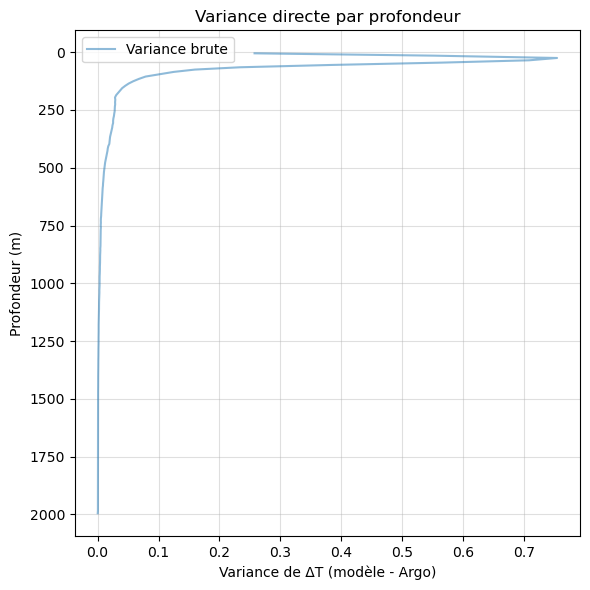

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d  # option pour lisser

# --- Données déjà calculées ---
var_profile_direct = np.array(var_profile_direct)
depth_centers_direct = np.array(depth_centers_direct)

# --- Plot ---
plt.figure(figsize=(6, 6))
plt.plot(var_profile_direct, depth_centers_direct, label="Variance brute", alpha=0.5)

plt.gca().invert_yaxis()  # profondeur vers le bas
plt.xlabel("Variance de ΔT (modèle - Argo)")
plt.ylabel("Profondeur (m)")
plt.title("Variance directe par profondeur")
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
import numba
import numpy as np
import xarray as xr


def interp_var_at_depth(var_depth, var_values, tag_depth):
    from scipy.interpolate import interp1d

    interp = interp1d(
        var_depth,  # profondeur bin (centres)
        var_values,  # variance associée
        bounds_error=False,
        fill_value=(var_values[0], var_values[-1]),
        axis=-1,
    )
    return interp(tag_depth)  # profondeur cible (profil Argo typiquement)

In [17]:
# Convertir en DataArray (plus pratique)
depth_da = xr.DataArray(depth_centers_direct, dims=["depth_bin"])
var_da = xr.DataArray(var_profile_direct, dims=["depth_bin"])

# Profondeurs Argo / modèle (au format xarray)
tag_pressure = reshaped_tag["pressure"]  # (obs,)

# interpolation VARIANCE DIRECTE à ces profondeurs
var_direct_interp = xr.apply_ufunc(
    interp_var_at_depth,
    depth_da,  # 1D
    var_da,  # 1D
    tag_pressure,  # (obs,) ou (profil, obs)
    input_core_dims=[["depth_bin"], ["depth_bin"], ["obs"]],
    output_core_dims=[["obs"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[var_da.dtype],
)
var_direct_interp

<xarray.DataArray (time: 454, obs: 5760)> Size: 21MB
dask.array<transpose, shape=(454, 5760), dtype=float64, chunksize=(1, 5760), chunktype=numpy.ndarray>
Coordinates:
  * obs      (obs) int64 46kB 0 1 2 3 4 5 6 ... 5754 5755 5756 5757 5758 5759
  * time     (time) datetime64[ns] 4kB 2022-08-09 2022-08-10 ... 2023-11-05

In [18]:
reference_model

<xarray.Dataset> Size: 108GB
Dimensions:             (lat: 481, lon: 913, time: 454, depth: 33)
Coordinates:
  * depth               (depth) float32 132B 0.494 1.541 2.646 ... 541.1 643.6
  * lat                 (lat) float32 2kB 20.0 20.08 20.17 ... 59.83 59.92 60.0
    latitude            (lat, lon) float32 2MB dask.array<chunksize=(300, 300), meta=np.ndarray>
  * lon                 (lon) float32 4kB -50.0 -49.92 -49.83 ... 25.92 26.0
    longitude           (lat, lon) float32 2MB dask.array<chunksize=(300, 300), meta=np.ndarray>
  * time                (time) datetime64[ns] 4kB 2022-08-09 ... 2023-11-05
Data variables:
    H0                  (lat, lon) float32 2MB dask.array<chunksize=(300, 300), meta=np.ndarray>
    TEMP                (time, depth, lat, lon) float64 53GB dask.array<chunksize=(23, 33, 300, 300), meta=np.ndarray>
    XE                  (time, lat, lon) float64 2GB dask.array<chunksize=(23, 300, 300), meta=np.ndarray>
    dynamic_bathymetry  (lat, lon, time) float64 2GB dask.array<chunksize=(300, 300, 23), meta=np.ndarray>
    dynamic_depth       (depth, time, lat, lon) float64 53GB dask.array<chunksize=(33, 23, 300, 300), meta=np.ndarray>
    mask                (depth, lat, lon) int8 14MB dask.array<chunksize=(33, 300, 300), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.4
    comment:      CMEMS product
    history:      2023/06/01 16:20:05 MERCATOR OCEAN Netcdf creation
    institution:  MERCATOR OCEAN
    references:   http://www.mercator-ocean.fr
    source:       MERCATOR GLORYS12V1
    title:        daily mean fields from Global Ocean Physics Analysis and Fo...

In [19]:
import numpy as np
from numba import njit


@njit
def fast_likelihood(tag_temp, model_temp, var_at_depth):
    diff_temp = (tag_temp - model_temp) ** 2 / (var_at_depth + 0.01)
    log_prob = -0.5 * (np.log(2 * np.pi) + np.log(var_at_depth + 0.01) + diff_temp)
    return np.exp(np.nanmean(log_prob))


def likelihood_fast(model_temp, model_depth, tag_temp, tag_depth, var_at_depth):
    from scipy.interpolate import interp1d

    mask = ~np.isnan(tag_depth)
    tag_depth_ = tag_depth[mask]
    tag_temp_ = tag_temp[mask]
    var_at_depth_ = var_at_depth[mask]

    mask_model = np.isfinite(model_depth) & np.isfinite(model_temp)
    model_depth_ = model_depth[mask_model]
    model_temp_ = model_temp[mask_model]

    if model_depth_.size == 0:
        return np.nan

    model_temp_at_depth = interp1d(
        model_depth_,
        model_temp_,
        bounds_error=False,
        fill_value=(model_temp_[0], model_temp_[-1]),
    )(tag_depth_)

    return fast_likelihood(tag_temp_, model_temp_at_depth, var_at_depth_)


diff = xr.apply_ufunc(
    likelihood_fast,
    reference_model["TEMP"],
    reference_model["dynamic_depth"],
    reshaped_tag["temperature"],
    reshaped_tag["pressure"],
    var_direct_interp,
    input_core_dims=[["depth"], ["depth"], ["obs"], ["obs"], ["obs"]],
    output_core_dims=[[]],
    dask="parallelized",
    vectorize=True,
    output_dtypes=[reference_model["TEMP"].dtype],
)
diff = diff.to_dataset(name="diff").assign(
    {
        "H0": reference_model["H0"],
        "XE": reference_model["XE"],
        "ocean_mask": reference_model["H0"].notnull(),
    }
)
diff

<xarray.Dataset> Size: 3GB
Dimensions:     (lat: 481, lon: 913, time: 454)
Coordinates:
  * lat         (lat) float32 2kB 20.0 20.08 20.17 20.25 ... 59.83 59.92 60.0
    latitude    (lat, lon) float32 2MB dask.array<chunksize=(300, 300), meta=np.ndarray>
  * lon         (lon) float32 4kB -50.0 -49.92 -49.83 ... 25.83 25.92 26.0
    longitude   (lat, lon) float32 2MB dask.array<chunksize=(300, 300), meta=np.ndarray>
  * time        (time) datetime64[ns] 4kB 2022-08-09 2022-08-10 ... 2023-11-05
Data variables:
    diff        (time, lat, lon) float64 2GB dask.array<chunksize=(1, 300, 300), meta=np.ndarray>
    H0          (lat, lon) float32 2MB dask.array<chunksize=(300, 300), meta=np.ndarray>
    XE          (time, lat, lon) float64 2GB dask.array<chunksize=(23, 300, 300), meta=np.ndarray>
    ocean_mask  (lat, lon) bool 439kB dask.array<chunksize=(300, 300), meta=np.ndarray>

In [20]:
diff = diff.compute()

/srv/conda/envs/notebook/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 49.77 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [21]:
diff

<xarray.Dataset> Size: 3GB
Dimensions:     (lat: 481, lon: 913, time: 454)
Coordinates:
  * lat         (lat) float32 2kB 20.0 20.08 20.17 20.25 ... 59.83 59.92 60.0
    latitude    (lat, lon) float32 2MB 20.0 20.0 20.0 20.0 ... 60.0 60.0 60.0
  * lon         (lon) float32 4kB -50.0 -49.92 -49.83 ... 25.83 25.92 26.0
    longitude   (lat, lon) float32 2MB -50.0 -49.92 -49.83 ... 25.83 25.92 26.0
  * time        (time) datetime64[ns] 4kB 2022-08-09 2022-08-10 ... 2023-11-05
Data variables:
    diff        (time, lat, lon) float64 2GB 9.912e-26 8.276e-26 ... 1.131e-10
    H0          (lat, lon) float32 2MB 4.293e+03 4.211e+03 ... 47.3 52.74
    XE          (time, lat, lon) float64 2GB 0.2362 0.2393 ... -0.02686 -0.0296
    ocean_mask  (lat, lon) bool 439kB True True True True ... True True True

_We can detect abnormal data by looking at the number of non null values for each time step._

In [ ]:
diff["diff"].count(["lat", "lon"]).plot()
diff

In [22]:
diff.to_zarr(
    f"{target_root}/diff.zarr",
    mode="w",
    storage_options=storage_options,
    zarr_version=2,
)

del diff

/tmp/ipykernel_4707/3398803127.py:1: FutureWarning: zarr_version is deprecated, use zarr_format
  diff.to_zarr(


## 3. HEALPix regridding

In this step, we regrid the data from above to HEALPix coordinates. 

This is a complex process, composed of several steps such as defining the HEALPix grid, creating the target grid and computing interpolation weights

Fortunately though, `pangeo-fish` embarks high-level functions to do the work for us!

In [21]:
from pangeo_fish.helpers import open_diff_dataset, regrid_dataset

# Open the previous dataset (only necessary if you resume the notebook from here)
diff = open_diff_dataset(target_root=target_root, storage_options=storage_options)
diff

/home/ecap/CLAUDE/pangeo-fish-public/notebooks/../pangeo_fish/helpers.py:548: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  .pipe(lambda ds: ds.merge(ds[["latitude", "longitude"]].compute()))
/home/ecap/CLAUDE/pangeo-fish-public/notebooks/../pangeo_fish/helpers.py:548: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  .pipe(lambda ds: ds.

<xarray.Dataset> Size: 3GB
Dimensions:     (yi: 481, xi: 913, time: 454)
Coordinates:
    latitude    (yi, xi) float32 2MB 20.0 20.0 20.0 20.0 ... 60.0 60.0 60.0 60.0
    longitude   (yi, xi) float32 2MB -50.0 -49.92 -49.83 ... 25.83 25.92 26.0
  * time        (time) datetime64[ns] 4kB 2022-08-09 2022-08-10 ... 2023-11-05
Dimensions without coordinates: yi, xi
Data variables:
    H0          (yi, xi) float32 2MB dask.array<chunksize=(481, 913), meta=np.ndarray>
    XE          (time, yi, xi) float64 2GB dask.array<chunksize=(8, 481, 913), meta=np.ndarray>
    diff        (time, yi, xi) float64 2GB dask.array<chunksize=(57, 61, 115), meta=np.ndarray>
    ocean_mask  (yi, xi) bool 439kB dask.array<chunksize=(241, 913), meta=np.ndarray>

In [22]:
reshaped = regrid_dataset(
    ds=diff.compute(),
    refinement_level=refinement_level,
    min_vertices=min_vertices,
    rot=rot,
    dims=dims,
)[0]
reshaped

/home/ecap/micromamba/envs/pangeo-fish_debug/lib/python3.11/site-packages/xhealpixify/interpolation/mask.py:22: RuntimeWarning: invalid value encountered in divide
  return masked_weights / np.sum(masked_weights, axis=-1)[:, None]


<xarray.Dataset> Size: 313MB
Dimensions:     (cells: 42844, time: 454)
Coordinates:
    cell_ids    (cells) int64 343kB 10935 10939 10940 ... 327677 327678 327679
    latitude    (cells) float64 343kB 20.26 20.26 20.26 ... 41.41 41.41 41.61
    longitude   (cells) float64 343kB 24.26 23.55 23.91 ... 0.1758 -0.1758 0.0
  * time        (time) datetime64[ns] 4kB 2022-08-09 2022-08-10 ... 2023-11-05
    resolution  float64 8B 0.003997
Dimensions without coordinates: cells
Data variables:
    H0          (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    XE          (time, cells) float64 156MB dask.array<chunksize=(255, 42844), meta=np.ndarray>
    diff        (time, cells) float64 156MB dask.array<chunksize=(255, 42844), meta=np.ndarray>
    ocean_mask  (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
Attributes:
    grid_type:     healpix
    level:         8
    nside:         256
    lat:           0
    lon:           0
    rot_lat:       0
    rot_lon:       0
    comment:       pangeo-fish == 2026.3.0, healpix-convolution == 0.1.2, xar...
    min_vertices:  1

Let's plot the same chart as before to check that the HEALPix regridding hasn't changed the data

/home/ecap/micromamba/envs/pangeo-fish_debug/lib/python3.11/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 1.49 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


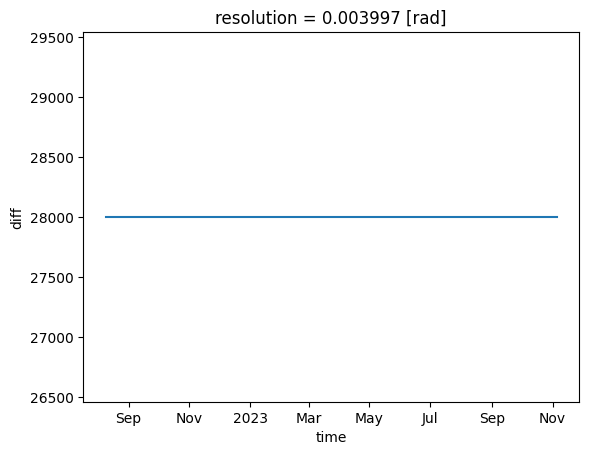

In [23]:
reshaped["diff"].count(dims).plot()

In [24]:
reshaped["diff"].dggs.decode(
    {"grid_name": "healpix", "level": 8, "indexing_scheme": "nested"}
).compute().dggs.explore()

MapWithControls(colorbar=Colorbar(colors=[[0.267004, 0.004874, 0.329415], [0.26851, 0.009605, 0.335427], [0.26…

In [25]:
reshaped["diff"] = (
    reshaped["diff"] / reshaped["diff"].sum(dim="cells", skipna=True).compute()
).compute()

/home/ecap/micromamba/envs/pangeo-fish_debug/lib/python3.11/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 1.49 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/ecap/micromamba/envs/pangeo-fish_debug/lib/python3.11/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 1.49 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [26]:
reshaped["diff"].sum()

<xarray.DataArray 'diff' ()> Size: 8B
array(454.)
Coordinates:
    resolution  float64 8B 0.003997

In [27]:
target_root

's3://gfts-ifremer/tuna_mediterranean/run/capetienne/bbox/level10/global_copernicus/20P0204_larger_bbox1'

In [14]:
# Saves the result
reshaped.chunk(default_chunk_dims).to_zarr(
    f"{target_root}/diff-regridded.zarr",
    mode="w",
    consolidated=True,
    compute=True,
    storage_options=storage_options,
    zarr_version=2,
)
del reshaped

/tmp/ipykernel_5184/1492199169.py:2: FutureWarning: zarr_version is deprecated, use zarr_format
  reshaped.chunk(default_chunk_dims).to_zarr(
/srv/conda/envs/notebook/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 1.64 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


## 4. Compute the emission probability distribution

In this step, we use the comparison result from the step above to construct the emission probability matrix.

This comparison is essentially he differences between the temperature measured by the tag and the reference sea temperature. 

The emission probability matrix represents the likelihood of observing a specific temperature difference given the model parameters and configurations.

In [10]:
from pangeo_fish.helpers import compute_emission_pdf

In [11]:
# Open the previous dataset (only necessary if you resume the notebook from here)
differences = xr.open_dataset(
    f"{target_root}/diff-regridded.zarr",
    engine="zarr",
    chunks={},
    storage_options=storage_options,
).pipe(lambda ds: ds.merge(ds[["latitude", "longitude"]].compute()))
# ... and compute the emission matrices

In [12]:
differences

<xarray.Dataset> Size: 313MB
Dimensions:     (cells: 42844, time: 454)
Coordinates:
    cell_ids    (cells) int64 343kB 10935 10939 10940 ... 327677 327678 327679
    latitude    (cells) float64 343kB 20.26 20.26 20.26 ... 41.41 41.41 41.61
    longitude   (cells) float64 343kB 24.26 23.55 23.91 ... 0.1758 -0.1758 0.0
    resolution  float64 8B 0.003997
  * time        (time) datetime64[ns] 4kB 2022-08-09 2022-08-10 ... 2023-11-05
Dimensions without coordinates: cells
Data variables:
    H0          (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    XE          (time, cells) float64 156MB dask.array<chunksize=(1, 42844), meta=np.ndarray>
    diff        (time, cells) float64 156MB dask.array<chunksize=(1, 42844), meta=np.ndarray>
    ocean_mask  (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
Attributes:
    comment:       pangeo-fish == 2025.3.4.dev20+g2e5c86fff.d20251210, healpi...
    grid_type:     healpix
    lat:           0
    level:         8
    lon:           0
    min_vertices:  1
    nside:         256
    rot_lat:       0
    rot_lon:       0

### I just create and add init + raw 

In [13]:
tag["tagging_events"].ds

<xarray.DatasetView> Size: 64B
Dimensions:     (event_name: 2)
Coordinates:
  * event_name  (event_name) object 16B 'release' 'fish_death'
Data variables:
    time        (event_name) datetime64[ns] 16B 2022-08-09T16:00:00 2023-11-0...
    longitude   (event_name) float64 16B -2.994 -1.861
    latitude    (event_name) float64 16B 47.13 46.57

In [14]:
emission_pdf = compute_emission_pdf(
    diff_ds=differences,
    events_ds=tag["tagging_events"].ds,
    differences_std=differences_std,
    initial_std=initial_std,
    recapture_std=recapture_std,
    dims=dims,
    chunk_time=chunk_time,
)[0]
emission_pdf["pdf"] = differences["diff"]
emission_pdf

good init
0.001
good final
<xarray.Dataset> Size: 64B
Dimensions:     ()
Coordinates:
    event_name  <U10 40B 'fish_death'
Data variables:
    time        datetime64[ns] 8B 2023-11-05T19:01:04
    longitude   float64 8B -1.861
    latitude    float64 8B 46.57
0.001


<xarray.Dataset> Size: 158MB
Dimensions:     (cells: 42844, time: 454)
Coordinates:
  * cell_ids    (cells) int64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    latitude    (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    longitude   (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    resolution  float64 8B 0.003997
  * time        (time) datetime64[ns] 4kB 2022-08-09 2022-08-10 ... 2023-11-05
Dimensions without coordinates: cells
Data variables:
    pdf         (time, cells) float64 156MB dask.array<chunksize=(1, 42844), meta=np.ndarray>
    initial     (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    final       (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    mask        (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
Indexes:
    cell_ids  HealpixIndex(level=8, indexing_scheme=nested)
Attributes:
    comment:          pangeo-fish == 2025.3.4.dev20+g2e5c86fff.d20251210, hea...
    grid_type:        healpix
    lat:              0
    level:            8
    lon:              0
    min_vertices:     1
    nside:            256
    rot_lat:          0
    rot_lon:          0
    differences_std:  1.0
    recapture_std:    0.001
    initial_std:      0.001

In [15]:
emission_pdf = emission_pdf.dggs.decode(
    {"grid_name": "healpix", "level": 8, "indexing_scheme": "nested"}
)
emission_pdf.final.compute().where(lambda x: x > 0).dggs.explore()

Map(custom_attribution='', layers=(SolidPolygonLayer(filled=True, get_fill_color=arro3.core.ChunkedArray<Fixed…

In [16]:
emission_pdf.pdf.compute().sum()

<xarray.DataArray 'pdf' ()> Size: 8B
array(454.)
Coordinates:
    resolution  float64 8B 0.003997

Whatever the temporal distribution looks like, they must **never** (i.e, at _any time step_) sum to 0.

How could we check that visually? You'd have guessed it by now: similarly as before!

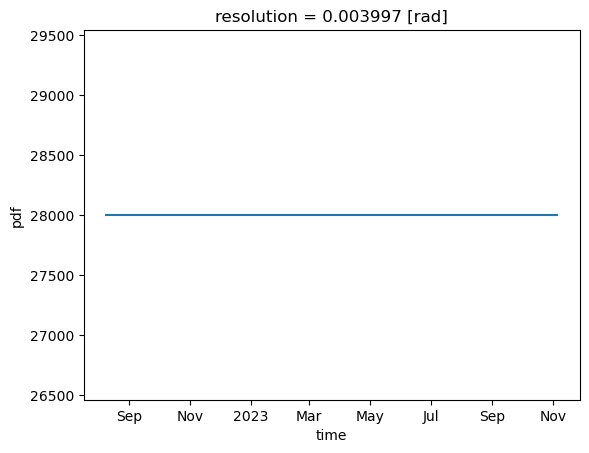

In [17]:
emission_pdf = emission_pdf.chunk(default_chunk_dims).persist()
emission_pdf["pdf"].count(dims).plot()

In [18]:
# Save the dataset
emission_pdf.compute().to_zarr(
    f"{target_root}/emission.zarr",
    mode="w",
    consolidated=True,
    storage_options=storage_options,
    zarr_version=2,
)

/tmp/ipykernel_5824/3772922378.py:2: FutureWarning: zarr_version is deprecated, use zarr_format
  emission_pdf.compute().to_zarr(


## 5. Adding Bathy pdf

In [7]:
import fsspec
from pangeo_fish.bathy import batch_compute_pdf_bathy
from pangeo_fish.cf import bounds_to_bins
from pangeo_fish.tags import adapt_model_time, reshape_by_bins, to_time_slice

# Ton chemin cible
zarr_path = f"{target_root}/bathy_pdf_{tag_name}.zarr"


fs = fsspec.filesystem("s3", **storage_options)
bool_bathy = fs.exists(zarr_path)

if bool_bathy:
    print(f"⚠️ Le fichier {zarr_path} existe déjà — calcul sauté.")
else:
    print(f"✅ Aucun fichier trouvé, lancement du calcul...")

if bool_bathy:
    bathy_pdf = xr.open_dataset(
        f"{target_root}/bathy_pdf_{tag_name}.zarr",
        engine="zarr",
        chunks={},
        storage_options=storage_options,
    )
else:
    import healpy as hp
    from pangeo_fish.bathy import compute_healpix_histogram_region_bin_size

    # Open the previous dataset (only necessary if you resume the notebook from here)
    full_bathy = xr.open_dataset(
        "s3://gfts-reference-data/gebco_2024_new.zarr",
        engine="zarr",
        chunks={},
        storage_options=storage_options,
    ).rename({"lat": "latitude", "lon": "longitude"})

    subset_bathy = full_bathy.sel(
        {dim: slice(bounds[0], bounds[1]) for dim, bounds in bbox.items()}
    )

    import numpy as np

    refinement_level = refinement_level

    ds_histo = compute_healpix_histogram_region_bin_size(
        subset_bathy,
        nside=nside,
        max_depth_m=1000,  # <- profondeur max désirée en mètres
        depth_bin_size=16,  # <- largeur d’un bin en mètres
    )

    hist_ids = ds_histo.cell_ids.values  # cell ids dans ton ds_histo
    pdf_ids = emission_pdf.cell_ids.values  # cell ids dans emission_pdf

    common = np.intersect1d(hist_ids, pdf_ids)
    # isel avec masque
    mask = np.isin(hist_ids, common)
    ds_histo.isel(cells=np.where(mask)[0])

    # Reshape the tag log, so that it bins to the time step of reference_model
    reshaped_tag = reshape_by_bins(
        tag_log,
        dim="time",
        bins=(
            reference_model.cf.add_bounds(["time"], output_dim="bounds")
            .pipe(bounds_to_bins, bounds_dim="bounds")
            .get("time_bins")
        ),
        other_dim="obs",
    ).chunk({"time": chunk_time})

    pdf_da_func = batch_compute_pdf_bathy(
        ds_histo,
        reshaped_tag,
        target_root,
        batch_size=1000,
    )
    sum_over_cells = pdf_da_func.sum(dim="cells", skipna=True)  # shape (time,)
    # Normalising
    bathy_pdf = pdf_da_func / sum_over_cells

    bathy_pdf.compute().to_zarr(
        f"{target_root}/bathy_pdf_{tag_name}.zarr",
        compute=True,
        mode="w",
        consolidated=True,
        zarr_version=2,
        storage_options=storage_options,
    )
    bathy_pdf = xr.open_dataset(
        f"{target_root}/bathy_pdf_{tag_name}.zarr",
        engine="zarr",
        chunks={},
        storage_options=storage_options,
    )

⚠️ Le fichier s3://gfts-ifremer/tuna_mediterranean/run/capetienne/bbox/level10/global_copernicus/20P0204_larger_bbox1/bathy_pdf_20P0204.zarr existe déjà — calcul sauté.


In [8]:
bathy_pdf = bathy_pdf.dggs.decode(
    {"grid_name": "healpix", "level": 8, "indexing_scheme": "nested"}
)
bathy_pdf.pdf_bathy.compute().where(lambda x: x > 0).dggs.explore()

In [20]:
reshaped_tag.isel(time=136).pressure.max().compute()

<xarray.DataArray 'pressure' ()> Size: 8B
array(407.5)
Coordinates:
    time     datetime64[ns] 8B 2022-12-23

In [17]:
import numpy as np
import xarray as xr


def normalize_pdf_by_mask(ds, mask_var="mask", pdf_var="pdf", tol=1e-12):
    mask_cells = ds[mask_var].astype(bool)

    mask_time = mask_cells.expand_dims(time=ds["time"]).transpose("time", "cells")

    n_valid_cells = int(mask_cells.sum().compute().item())
    if n_valid_cells == 0:
        raise ValueError(
            "Le masque indique 0 cellules valides (océan). Impossible de normaliser."
        )
    sums_by_time = ds[pdf_var].where(mask_time).fillna(0).sum(dim="cells")
    sums_vals = sums_by_time.compute()
    to_fix = (sums_vals <= tol) | np.isnan(sums_vals)
    idxs = np.where(to_fix.values)[0]
    times = [str(t) for t in ds["time"].isel(time=idxs).values] if idxs.size else []
    print(
        f"{int(to_fix.sum().item())} pas de temps non valides. Indices: {idxs.tolist()}. Times: {times}"
    )
    if idxs.size == 0:
        return ds
    fill_per_time = xr.where(to_fix, 1.0 / float(n_valid_cells), np.nan)
    fill_per_time = xr.DataArray(
        fill_per_time, coords={"time": ds["time"]}, dims=["time"]
    )
    replacement = xr.where(mask_time, fill_per_time, np.nan)
    ds_fixed = ds.copy()
    ds_fixed[pdf_var] = xr.where(to_fix, replacement, ds[pdf_var])
    return ds_fixed

In [22]:
bathy_pdf["mask"] = emission_pdf["mask"]
bathy_pdf_corrected = normalize_pdf_by_mask(bathy_pdf, pdf_var="pdf_bathy")

0 pas de temps non valides. Indices: []. Times: []


In [23]:
bathy_pdf_corrected

<xarray.Dataset> Size: 157MB
Dimensions:     (cells: 42844, time: 454)
Coordinates:
  * cell_ids    (cells) int64 343kB dask.array<chunksize=(21422,), meta=np.ndarray>
  * time        (time) datetime64[ns] 4kB 2022-08-09 2022-08-10 ... 2023-11-05
    latitude    (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    longitude   (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    resolution  float64 8B 0.003997
Dimensions without coordinates: cells
Data variables:
    pdf_bathy   (time, cells) float64 156MB dask.array<chunksize=(29, 5356), meta=np.ndarray>
    mask        (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
Indexes:
    cell_ids  HealpixIndex(level=8, indexing_scheme=nested)

In [24]:
emission_pdf_corrected = normalize_pdf_by_mask(emission_pdf)

0 pas de temps non valides. Indices: []. Times: []


In [25]:
bathy_pdf_corrected = bathy_pdf_corrected.dggs.decode(
    {"grid_name": "healpix", "level": 8, "indexing_scheme": "nested"}
)

In [26]:
emission_pdf_corrected = emission_pdf_corrected.dggs.decode(
    {"grid_name": "healpix", "level": 8, "indexing_scheme": "nested"}
)

In [27]:
emission_with_bathy = emission_pdf_corrected.merge(
    bathy_pdf_corrected, compat="override"
)
emission_with_bathy

<xarray.Dataset> Size: 313MB
Dimensions:     (cells: 42844, time: 454)
Coordinates:
  * cell_ids    (cells) int64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    latitude    (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    longitude   (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    resolution  float64 8B 0.003997
  * time        (time) datetime64[ns] 4kB 2022-08-09 2022-08-10 ... 2023-11-05
Dimensions without coordinates: cells
Data variables:
    pdf         (time, cells) float64 156MB dask.array<chunksize=(1, 42844), meta=np.ndarray>
    initial     (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    final       (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    mask        (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    pdf_bathy   (time, cells) float64 156MB dask.array<chunksize=(29, 5356), meta=np.ndarray>
Indexes:
    cell_ids  HealpixIndex(level=8, indexing_scheme=nested)
Attributes:
    comment:          pangeo-fish == 2025.3.4.dev20+g2e5c86fff.d20251210, hea...
    grid_type:        healpix
    lat:              0
    level:            8
    lon:              0
    min_vertices:     1
    nside:            256
    rot_lat:          0
    rot_lon:          0
    differences_std:  1.0
    recapture_std:    0.001
    initial_std:      0.001

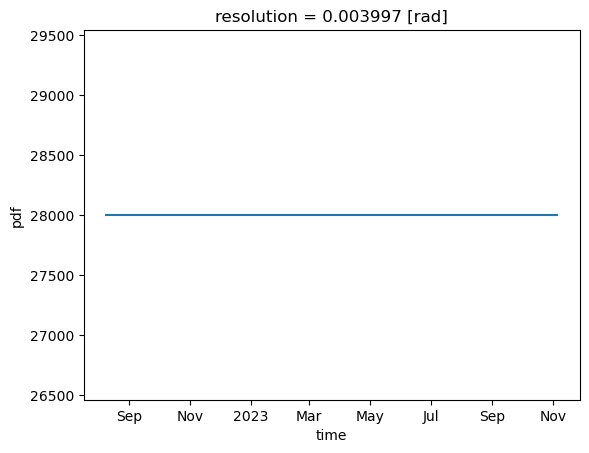

In [28]:
emission_with_bathy["pdf"].count(dims).plot()

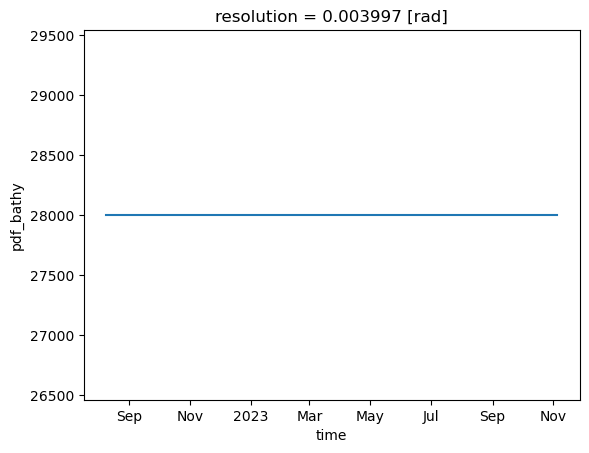

In [29]:
emission_with_bathy["pdf_bathy"].count(dims).plot()

In [30]:
from pangeo_fish.helpers import normalize_pdf

combined_diff_bathy = normalize_pdf(
    ds=emission_with_bathy,
    chunks=default_chunk_dims,
    dims=dims,
)[0]
combined_diff_bathy

<xarray.Dataset> Size: 158MB
Dimensions:     (cells: 42844, time: 454)
Coordinates:
  * cell_ids    (cells) int64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    latitude    (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    longitude   (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    resolution  float64 8B 0.003997
  * time        (time) datetime64[ns] 4kB 2022-08-09 2022-08-10 ... 2023-11-05
Dimensions without coordinates: cells
Data variables:
    initial     (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    final       (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    mask        (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    pdf         (time, cells) float64 156MB dask.array<chunksize=(1, 42844), meta=np.ndarray>
Indexes:
    cell_ids  HealpixIndex(level=8, indexing_scheme=nested)
Attributes:
    comment:          pangeo-fish == 2025.3.4.dev20+g2e5c86fff.d20251210, hea...
    grid_type:        healpix
    lat:              0
    level:            8
    lon:              0
    min_vertices:     1
    nside:            256
    rot_lat:          0
    rot_lon:          0
    differences_std:  1.0
    recapture_std:    0.001
    initial_std:      0.001

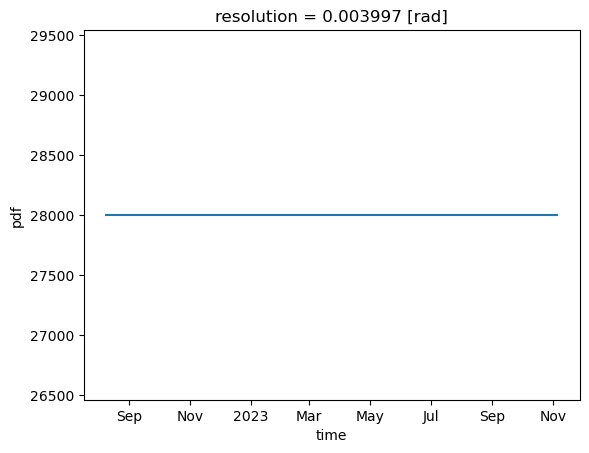

In [31]:
combined_diff_bathy["pdf"].count(dims).plot()

In [32]:
combined_diff_bathy

<xarray.Dataset> Size: 158MB
Dimensions:     (cells: 42844, time: 454)
Coordinates:
  * cell_ids    (cells) int64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    latitude    (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    longitude   (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    resolution  float64 8B 0.003997
  * time        (time) datetime64[ns] 4kB 2022-08-09 2022-08-10 ... 2023-11-05
Dimensions without coordinates: cells
Data variables:
    initial     (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    final       (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    mask        (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    pdf         (time, cells) float64 156MB dask.array<chunksize=(1, 42844), meta=np.ndarray>
Indexes:
    cell_ids  HealpixIndex(level=8, indexing_scheme=nested)
Attributes:
    comment:          pangeo-fish == 2025.3.4.dev20+g2e5c86fff.d20251210, hea...
    grid_type:        healpix
    lat:              0
    level:            8
    lon:              0
    min_vertices:     1
    nside:            256
    rot_lat:          0
    rot_lon:          0
    differences_std:  1.0
    recapture_std:    0.001
    initial_std:      0.001

In [33]:
combined_diff_bathy.pdf.compute().sum()

<xarray.DataArray 'pdf' ()> Size: 8B
array(454.)
Coordinates:
    resolution  float64 8B 0.003997

In [34]:
combined_diff_bathy = combined_diff_bathy.dggs.decode(
    {"grid_name": "healpix", "level": 8, "indexing_scheme": "nested"}
)
combined_diff_bathy.pdf.compute().dggs.explore()

In [35]:
combined_diff_bathy.compute().to_zarr(
    f"{target_root}/emission_w_bathy_pdf_{tag_name}.zarr",
    compute=True,
    mode="w",
    consolidated=True,
    zarr_version=2,
    storage_options=storage_options,
)
del emission_pdf, combined_diff_bathy

/tmp/ipykernel_5824/3410565792.py:1: FutureWarning: zarr_version is deprecated, use zarr_format
  combined_diff_bathy.compute().to_zarr(


## 6. Adding Light PDF (solar threshold)

This chapter uses the raw DST light record to detect sunrise and sunset events, self-calibrate the solar elevation threshold, evaluate event quality, and compute per-night solar likelihood maps.

All functions come from `pangeo_fish.light`.


In [28]:
import pandas as pd
import numpy as np
import ephem

# ── Load raw DST data from the tag DataTree ────────────────────────────────
# tag["/dst"].ds has a single time dimension (2.6 M rows at ~15-s resolution).
df_raw = (
    tag["/dst"].ds[["light", "pressure", "temperature"]]
    .to_dataframe()
    .reset_index()
)
df_raw["time"] = pd.to_datetime(df_raw["time"], utc=True)
df_raw = df_raw.sort_values("time").set_index("time")

# ── Resample to 1-minute resolution ───────────────────────────────────────
# light: max  — captures the peak at each threshold crossing
# pressure, temperature: mean
df = df_raw.resample("1min").agg(
    {"light": "max", "pressure": "mean", "temperature": "mean"}
)
df = df.dropna(subset=["light"]).reset_index()

print(f"{len(df):,} records, {df['time'].min().date()} → {df['time'].max().date()}")
print(f"Light:    {df['light'].min():.0f}–{df['light'].max():.0f} counts")
print(f"Pressure: 0–{df['pressure'].max():.0f} dbar")


652,470 records, 2022-08-09 → 2023-11-06
Light:    20–219 counts
Pressure: 0–566 dbar


In [29]:
import pandas as pd
import numpy as np
import ephem

# ── Path to the raw tag CSV ────────────────────────────────────────────────
LIGHT_FILEPATH = "20P0204/dst.csv"  # <-- set this to your CSV path

# ── Load and resample to 1-minute resolution ───────────────────────────────
df_raw = pd.read_csv(
    LIGHT_FILEPATH,
    usecols=["time", "light", "pressure", "temperature"],
)
df_raw["time"] = pd.to_datetime(df_raw["time"], utc=True)
df_raw = df_raw.sort_values("time").set_index("time")

df = df_raw.resample("1min").agg(
    {"light": "max", "pressure": "mean", "temperature": "mean"}
)
df = df.dropna(subset=["light"]).reset_index()

print(f"{len(df)} records, {df['time'].min().date()} → {df['time'].max().date()}")
print(f"Light: {df['light'].min():.0f}–{df['light'].max():.0f} counts")
print(f"Depth: 0–{df['pressure'].max():.0f} dbar")


652470 records, 2022-08-09 → 2023-11-06
Light: 20–219 counts
Depth: 0–566 dbar


In [30]:
# Extract release position from tag metadata
release = tag["tagging_events"].ds.sel(event_name="release")
RELEASE_LON = float(release["longitude"].values)
RELEASE_LAT = float(release["latitude"].values)
print(f"Release position: {RELEASE_LON:.3f}°E, {RELEASE_LAT:.3f}°N")


Release position: -2.994°E, 47.129°N


### 6.1 Sensor check

Verify that the tag has a usable light sensor before running the pipeline.


In [31]:
# ── Sensor check ──────────────────────────────────────────────────────────
has_light = (
    "light" in df.columns
    and not df["light"].isna().all()
    and (df["light"].max() - df["light"].min()) > 50
)

if has_light:
    print(f"✅ Light sensor exploitable. Range: "
          f"{df['light'].max() - df['light'].min():.0f} counts.")
else:
    print(
        "⚠️  Light sensor not exploitable — "
        "skipping light and moon chapters."
    )
    # Uncomment to halt notebook execution:
    # raise SystemExit("No usable light sensor.")


✅ Light sensor exploitable. Range: 199 counts.


### 6.2 Parameters

All knobs for the solar pipeline in one place.


In [32]:
# ── Solar pipeline parameters ──────────────────────────────────────────────
THRESH_LIGHT_BASE = 60      # baseline dynamic threshold (counts) on new-moon night
THRESH_LIGHT_AMP  = 20      # moon-phase amplitude correction (counts)
THRESH_DEG_INIT   = -11.0   # initial solar elevation threshold; will be self-calibrated
SIGMA_TIMING_MIN  = 18      # timing uncertainty (minutes)
MAX_DEPTH_DBAR    = 80      # quality filter: max depth in twilight window (dbar)
MIN_LIGHT_RANGE   = 60      # quality filter: minimum Δlight (counts)
GAUSSIAN_SMOOTH   = 1.0     # spatial smoothing sigma (pixels)
N_CALIB_NIGHTS    = 20      # number of nights used for self-calibration

# ── Solar grid: bbox + 1° margin on each side ────────────────────────────
# The +1° margin ensures all HEALPix cells in the emission bbox are covered
# after regridding, so the intersection with the emission equals the full
# emission domain (no silent cell loss at the edges).
LONS = np.arange(bbox["longitude"][0] - 1, bbox["longitude"][1] + 2, 1.0)
LATS = np.arange(bbox["latitude"][0]  - 1, bbox["latitude"][1]  + 2, 1.0)


### 6.3 Apply dynamic threshold

Raise the light threshold on bright-moon nights to avoid misclassifying moonlight as daylight.


In [33]:
from pangeo_fish.light import dynamic_threshold

print("Computing lunar phases…")
df["time_h"] = df["time"].dt.round("h")
times_h = df["time_h"].unique()

moon_phases = []
for t in times_h:
    m = ephem.Moon(pd.Timestamp(t).strftime("%Y/%m/%d %H:%M:%S"))
    moon_phases.append({"time_h": t, "moon_phase": float(m.phase)})

moon_df = pd.DataFrame(moon_phases).set_index("time_h")
df = df.merge(moon_df, left_on="time_h", right_index=True, how="left")
df["dyn_thresh"] = dynamic_threshold(
    df["moon_phase"], base=THRESH_LIGHT_BASE, amp=THRESH_LIGHT_AMP
)
print(f"Dynamic threshold range: {df['dyn_thresh'].min():.1f}–{df['dyn_thresh'].max():.1f}")


Computing lunar phases…
Dynamic threshold range: 60.0–80.0


### 6.4 Visualise the raw light signal

Two-panel plot: light + dynamic threshold (top), depth (bottom). This is the 'is the signal usable?' eyeball check.


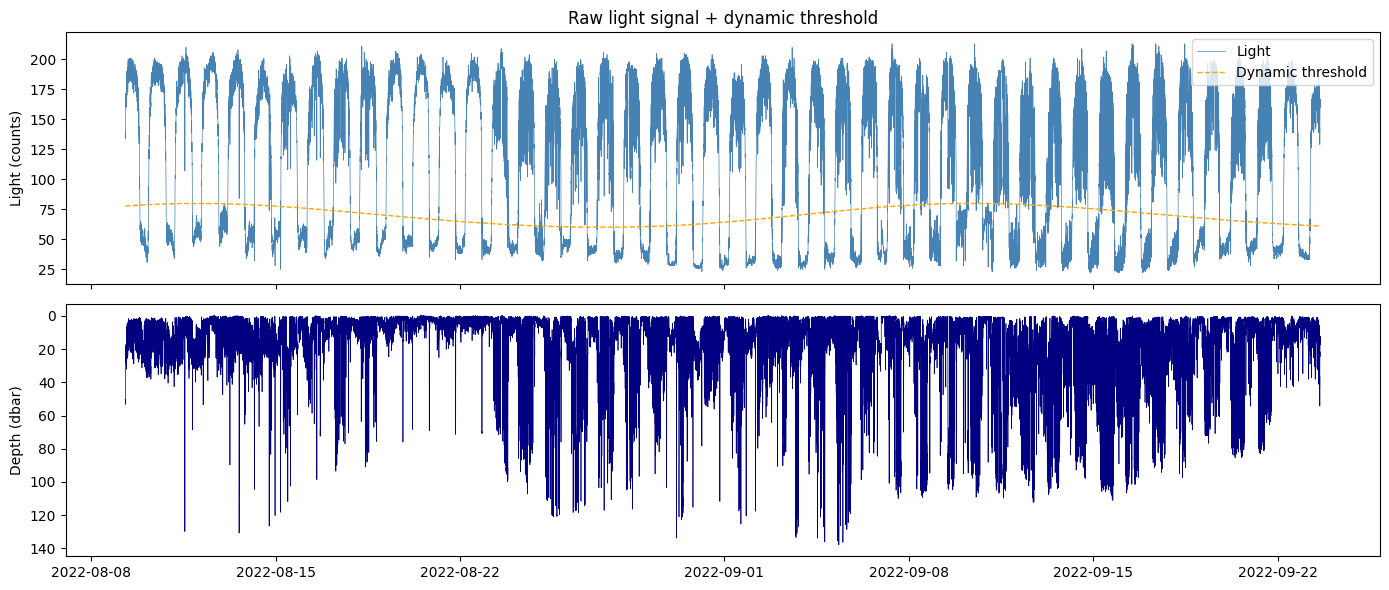

In [34]:
import matplotlib.pyplot as plt

early = df[df["time"] < df["time"].iloc[len(df) // 10]].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax = axes[0]
ax.plot(early["time"], early["light"], lw=0.5, color="steelblue", label="Light")
ax.plot(early["time"], early["dyn_thresh"], lw=1.0, color="orange",
        linestyle="--", label="Dynamic threshold")
ax.set_ylabel("Light (counts)")
ax.legend(loc="upper right")
ax.set_title("Raw light signal + dynamic threshold")

ax = axes[1]
ax.plot(early["time"], early["pressure"], lw=0.5, color="navy")
ax.set_ylabel("Depth (dbar)")
ax.invert_yaxis()

plt.tight_layout()
plt.show()


### 6.5 Detect twilight events


In [35]:
from pangeo_fish.light import detect_twilight_events

pairs = detect_twilight_events(
    df,
    release_lon=RELEASE_LON,
    release_lat=RELEASE_LAT,
    window_h=2.5,
)
print(f"Paired nights: {len(pairs)}")


Paired nights: 449


### 6.6 Sample week — detected transitions


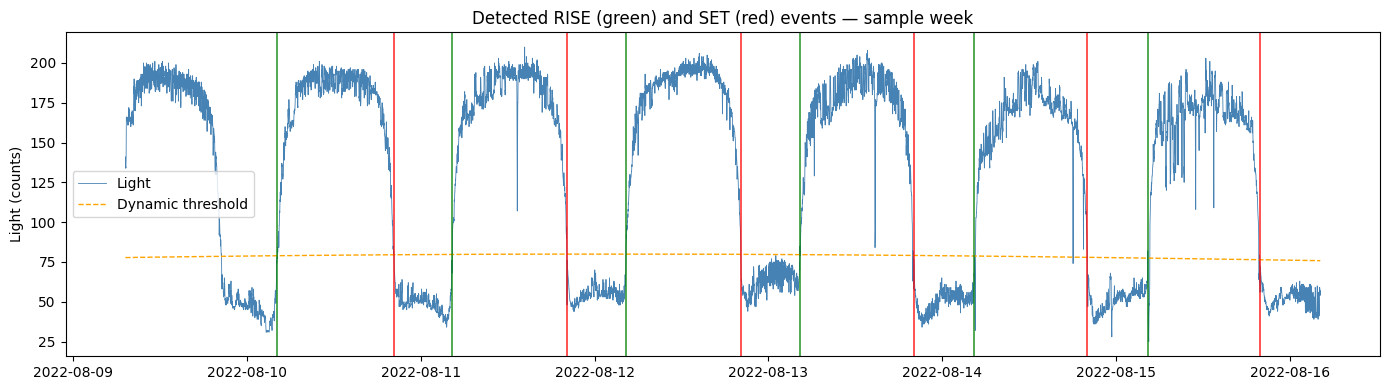

In [36]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

t_start = pairs[0][0] - pd.Timedelta(days=1)
t_end   = t_start + pd.Timedelta(days=7)
sample  = df[(df["time"] >= t_start) & (df["time"] <= t_end)]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sample["time"], sample["light"], lw=0.6, color="steelblue", label="Light")
ax.plot(sample["time"], sample["dyn_thresh"], lw=1.0, color="orange",
        linestyle="--", label="Dynamic threshold")

for t_rise, t_set in pairs:
    if t_start <= t_rise <= t_end:
        ax.axvline(t_rise, color="green", lw=1.2, alpha=0.8)
    if t_start <= t_set <= t_end:
        ax.axvline(t_set, color="red", lw=1.2, alpha=0.8)

ax.set_ylabel("Light (counts)")
ax.set_title("Detected RISE (green) and SET (red) events — sample week")
ax.legend()
plt.tight_layout()
plt.show()


### 6.7 Self-calibrate the solar elevation threshold

Using the first `N_CALIB_NIGHTS` nights at the self-calibrated longitude.


Self-calibrated longitude : -3.19°E  (release: -2.99°E)
Calibrated threshold      : -7.66°
Elevation std             : 1.49°


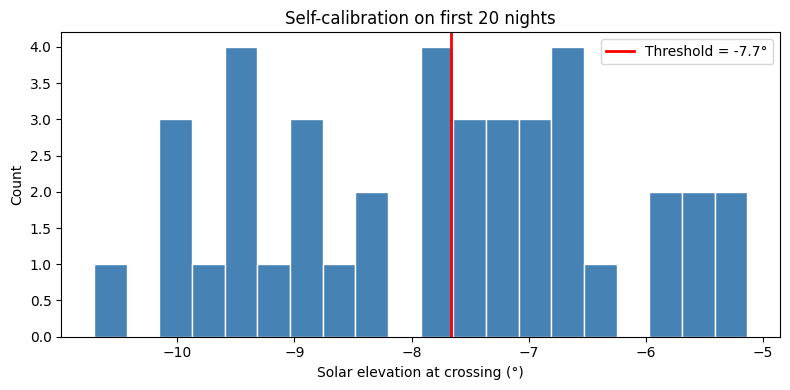

In [37]:
from pangeo_fish.light import self_calibrate_solar_threshold

calib = self_calibrate_solar_threshold(
    pairs, df,
    n_nights=N_CALIB_NIGHTS,
    release_lon=RELEASE_LON,
    release_lat=RELEASE_LAT,
)
THRESH_DEG = calib.thresh_deg

print(f"Self-calibrated longitude : {calib.lon_self:.2f}°E  (release: {RELEASE_LON:.2f}°E)")
print(f"Calibrated threshold      : {THRESH_DEG:.2f}°")
print(f"Elevation std             : {np.std(calib.elevations):.2f}°")

# Elevation distribution plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(calib.elevations, bins=20, color="steelblue", edgecolor="white")
ax.axvline(THRESH_DEG, color="red", lw=2, label=f"Threshold = {THRESH_DEG:.1f}°")
ax.set_xlabel("Solar elevation at crossing (°)")
ax.set_ylabel("Count")
ax.set_title(f"Self-calibration on first {N_CALIB_NIGHTS} nights")
ax.legend()
plt.tight_layout()
plt.show()


### 6.8 Compute quality flags


In [38]:
from pangeo_fish.light import compute_quality_flags

qdf = compute_quality_flags(df, pairs, max_depth=MAX_DEPTH_DBAR)

n_good    = qdf["flag"].eq("good").sum()
n_partial = qdf["flag"].eq("partial").sum()
n_bad     = qdf["flag"].eq("bad").sum()
n_total   = len(qdf)
print(f"Quality: {n_good} good ({100*n_good/n_total:.0f}%), "
      f"{n_partial} partial ({100*n_partial/n_total:.0f}%), "
      f"{n_bad} bad ({100*n_bad/n_total:.0f}%)")
print(f"Usable (good+partial): {n_good+n_partial}/{n_total}")


Quality: 267 good (59%), 88 partial (20%), 94 bad (21%)
Usable (good+partial): 355/449


### 6.9 Quality diagnostics (3-panel)


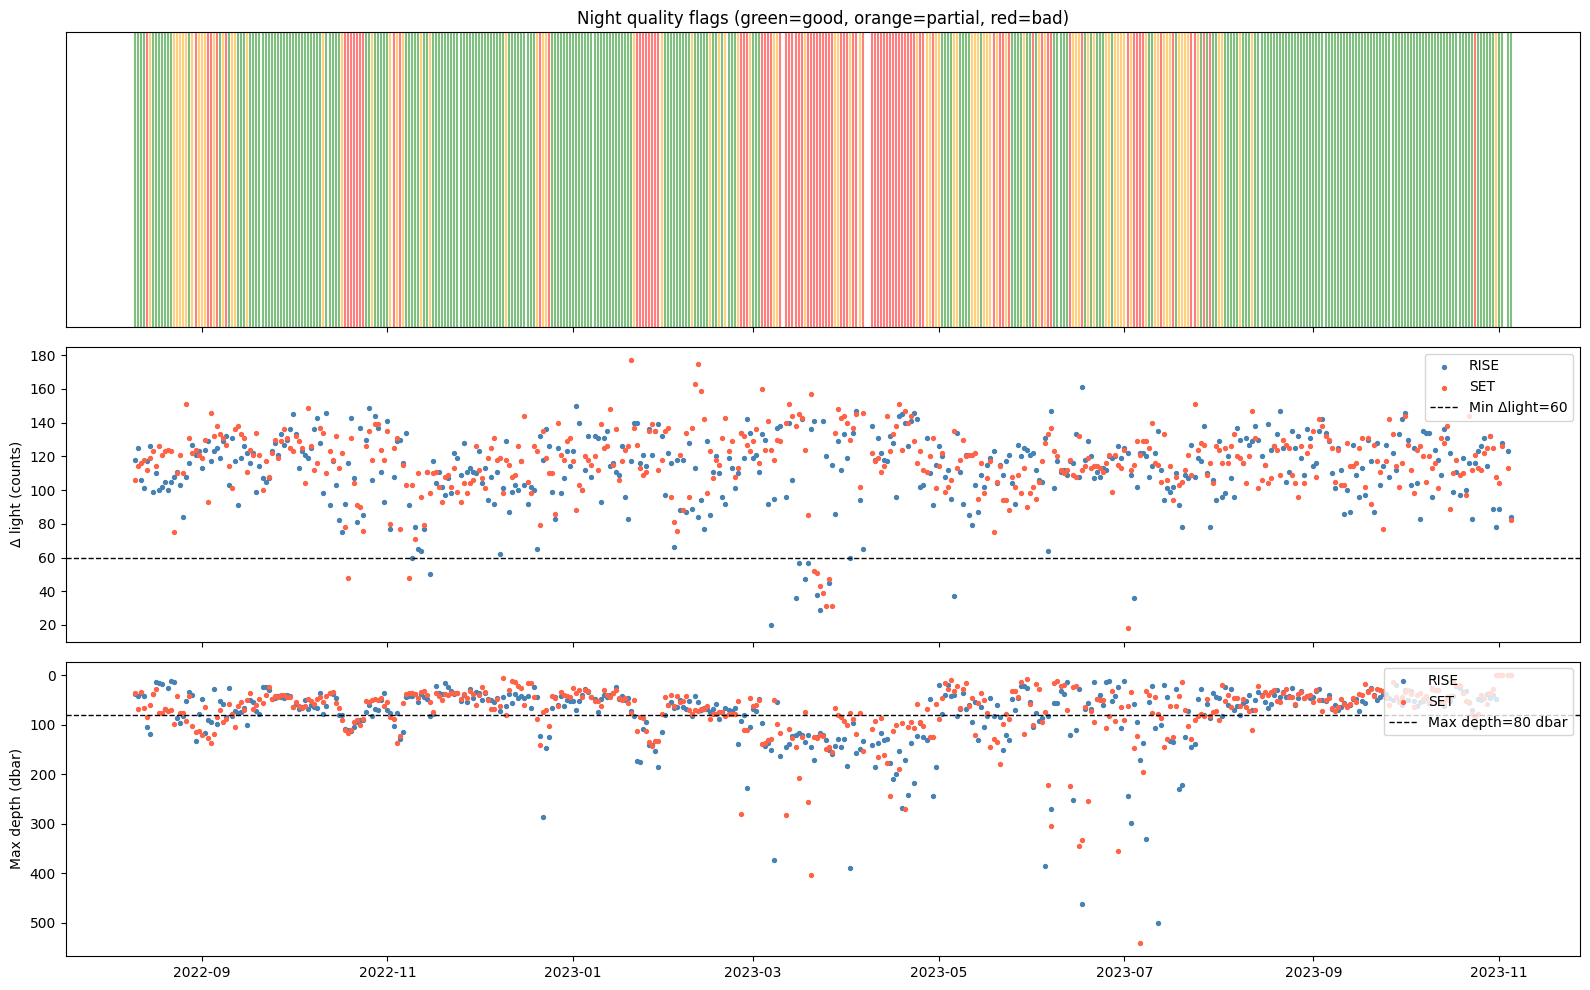

In [39]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

COLOR_MAP = {"good": "green", "partial": "orange", "bad": "red"}

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# Panel 1: quality flags timeline
ax = axes[0]
for _, row in qdf.iterrows():
    ax.axvline(row["date"], color=COLOR_MAP[row["flag"]], alpha=0.5, lw=1.5)
ax.set_yticks([])
ax.set_title("Night quality flags (green=good, orange=partial, red=bad)")

# Panel 2: Δlight per event
ax = axes[1]
ax.scatter(qdf["date"], qdf["dl_rise"], s=8, color="steelblue", label="RISE")
ax.scatter(qdf["date"], qdf["dl_set"], s=8, color="tomato", label="SET")
ax.axhline(MIN_LIGHT_RANGE, lw=1, ls="--", color="black", label=f"Min Δlight={MIN_LIGHT_RANGE}")
ax.set_ylabel("Δ light (counts)")
ax.legend(loc="upper right")

# Panel 3: max depth per event
ax = axes[2]
ax.scatter(qdf["date"], qdf["dp_rise"], s=8, color="steelblue", label="RISE")
ax.scatter(qdf["date"], qdf["dp_set"], s=8, color="tomato", label="SET")
ax.axhline(MAX_DEPTH_DBAR, lw=1, ls="--", color="black", label=f"Max depth={MAX_DEPTH_DBAR} dbar")
ax.set_ylabel("Max depth (dbar)")
ax.invert_yaxis()
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()


### 6.10 Day-length over time (equinox diagnostic)


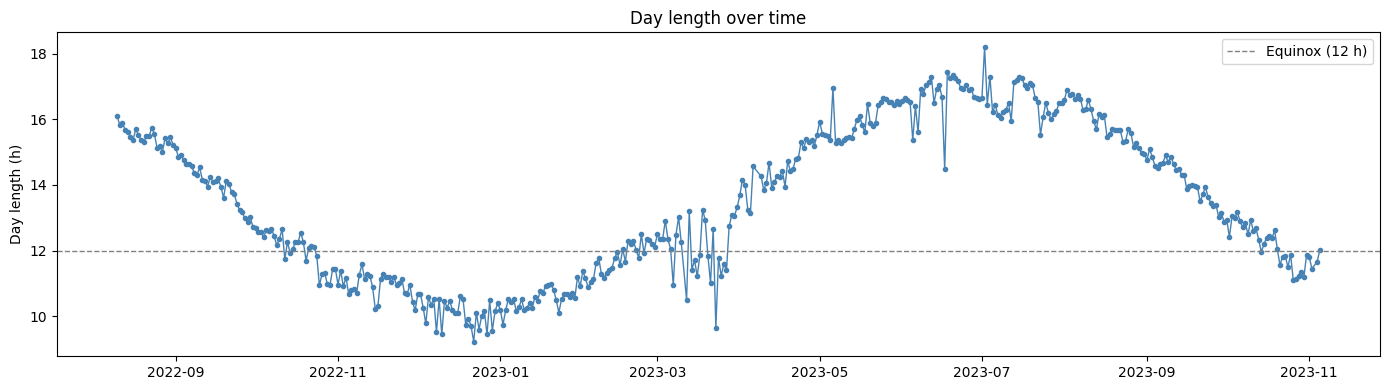

In [40]:
from pangeo_fish.light.quality import _tz

day_lengths = [
    (_tz(t_set) - _tz(t_rise)).total_seconds() / 3600
    for t_rise, t_set in pairs
]
dates = [pd.Timestamp(t_rise.date()) for t_rise, t_set in pairs]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dates, day_lengths, "o-", ms=3, lw=1, color="steelblue")
ax.axhline(12, ls="--", color="gray", lw=1, label="Equinox (12 h)")
ax.set_ylabel("Day length (h)")
ax.set_title("Day length over time")
ax.legend()
plt.tight_layout()
plt.show()


### 6.11 Compute solar likelihood maps

This uses the calibrated threshold and applies the quality-aware Gaussian timing model. **This cell is slow** (~1 s/night for a 1° grid).


In [41]:
import time as tmod
from pangeo_fish.light import compute_solar_likelihood

print(f"Computing {len(pairs)} nights × {len(LATS)*len(LONS)} pixels…")
t0 = tmod.time()

pdf_light_latlon = compute_solar_likelihood(
    pairs,
    qdf,
    lons=LONS,
    lats=LATS,
    thresh_deg=THRESH_DEG,
    sigma_timing=SIGMA_TIMING_MIN,
    smooth_sigma=GAUSSIAN_SMOOTH,
)

print(f"Done in {tmod.time()-t0:.0f}s")
print(pdf_light_latlon)


Computing 449 nights × 3397 pixels…
Done in 222s
<xarray.DataArray 'pdf_light' (time: 449, latitude: 43, longitude: 79)> Size: 12MB
array([[[2.16151494e-52, 1.67681960e-50, 1.19603094e-48, ...,
         1.48326254e-21, 1.17398950e-22, 9.03470851e-24],
        [3.47542415e-52, 2.69565145e-50, 1.92242161e-48, ...,
         2.35688421e-21, 1.86516513e-22, 1.43514599e-23],
        [6.38138219e-52, 4.94864234e-50, 3.52847896e-48, ...,
         4.26794901e-21, 3.37690786e-22, 2.59785100e-23],
        ...,
        [4.00616687e-50, 3.03457064e-48, 2.11416661e-46, ...,
         5.04252684e-20, 3.90342283e-21, 2.93411062e-22],
        [4.31639181e-51, 3.26398616e-49, 2.27017910e-47, ...,
         4.81328291e-21, 3.72007241e-22, 2.79160909e-23],
        [3.37556178e-52, 2.54763144e-50, 1.76857562e-48, ...,
         3.28355890e-22, 2.53326768e-23, 1.89742687e-24]],

       [[2.82453840e-50, 2.10473747e-48, 1.44285529e-46, ...,
         1.09901954e-20, 8.37669611e-22, 6.19411660e-23],
        [4.22

### 6.12 Interactive likelihood slider

Browse per-night likelihood maps. Color encodes quality flag.


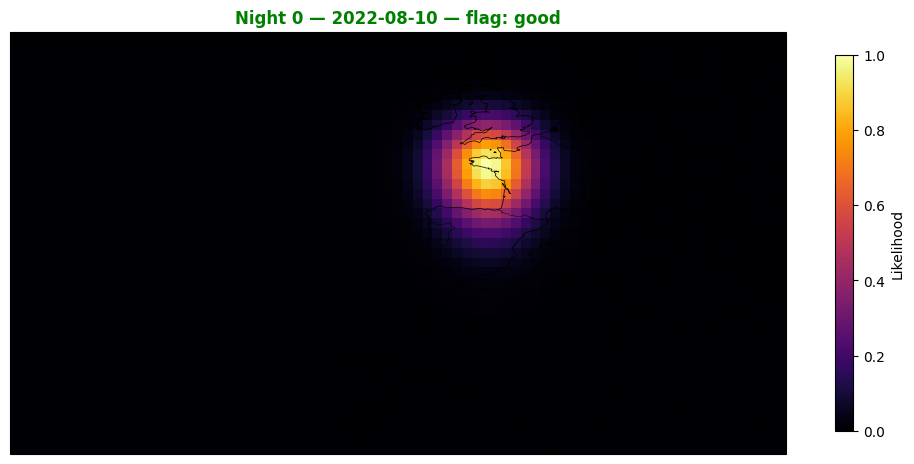

interactive(children=(IntSlider(value=0, description='Night:', max=448), Output()), _dom_classes=('widget-inte…

In [42]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

FLAG_COLORS = {"good": "green", "partial": "orange", "bad": "red"}

def show_night(night_idx):
    flag = qdf.iloc[night_idx]["flag"]
    date = qdf.iloc[night_idx]["date"]
    lh = pdf_light_latlon.isel(time=night_idx).values

    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
    im = ax.pcolormesh(
        LONS, LATS, lh,
        cmap="inferno", transform=ccrs.PlateCarree(), vmin=0, vmax=1,
    )
    ax.add_feature(cfeature.COASTLINE, lw=0.5)
    ax.add_feature(cfeature.BORDERS, lw=0.3)
    ax.set_title(
        f"Night {night_idx} — {date.date()} — flag: {flag}",
        color=FLAG_COLORS.get(flag, "black"), fontweight="bold",
    )
    plt.colorbar(im, ax=ax, shrink=0.8, label="Likelihood")
    plt.tight_layout()
    plt.show()

slider = widgets.IntSlider(min=0, max=len(pairs)-1, step=1, description="Night:")
widgets.interactive(show_night, night_idx=slider)


### 6.13 Regrid `pdf_light` to HEALPix

Convert the lat/lon likelihood DataArray to the HEALPix grid used by the rest of the pipeline.


In [43]:
import xarray as xr
import numpy as np
from xhealpixify import HealpyRegridder, HealpyGridInfo
from pangeo_fish.grid import center_longitude

# Build xr.Dataset with lat2d/lon2d coordinates required by HealpyRegridder
ds_light_latlon = pdf_light_latlon.to_dataset(name="pdf_light")

lon2d, lat2d = np.meshgrid(LONS, LATS)
ds_light_latlon = ds_light_latlon.assign_coords(
    lat2d=(("latitude", "longitude"), lat2d),
    lon2d=(("latitude", "longitude"), lon2d),
)

# Normalize each time step before regridding
ds_light_latlon["pdf_light"] = (
    ds_light_latlon["pdf_light"]
    / ds_light_latlon["pdf_light"].sum(dim=("latitude", "longitude"), skipna=True)
)

# Build HEALPix target grid at the same level as the emission PDF
grid_info = HealpyGridInfo(level=refinement_level)
target_grid = grid_info.target_grid(ds_light_latlon).pipe(center_longitude, 0)

regridder_light = HealpyRegridder(
    ds_light_latlon[["longitude", "latitude"]],
    target_grid,
    method="bilinear",
    interpolation_kwargs={"min_vertices": 1},
)
pdf_light_healpix = regridder_light.regrid_ds(ds_light_latlon).compute()

print("HEALPix pdf_light:")
print(pdf_light_healpix)


/home/ecap/micromamba/envs/pangeo-fish_debug/lib/python3.11/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 17.26 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


HEALPix pdf_light:
<xarray.Dataset> Size: 166MB
Dimensions:     (cells: 46028, time: 449)
Coordinates:
    cell_ids    (cells) uint64 368kB 10815 10831 10851 ... 327677 327678 327679
    latitude    (cells) float64 368kB 19.31 19.31 19.31 ... 41.41 41.41 41.61
    longitude   (cells) float64 368kB 25.31 26.72 26.02 ... 0.1758 -0.1758 0.0
  * time        (time) datetime64[ns] 4kB 2022-08-10 2022-08-11 ... 2023-11-05
    resolution  float64 8B 0.003997
Dimensions without coordinates: cells
Data variables:
    pdf_light   (time, cells) float64 165MB 1.716e-23 6.418e-25 ... 0.001176
Attributes:
    grid_type:  healpix
    level:      8
    nside:      256
    lat:        0
    lon:        0
    rot_lat:    0
    rot_lon:    0


## 7. Adding Moon PDF (lunar template-fit)

This chapter identifies nights during which the fish was shallow and the moon was bright, correlates the observed sub-surface light with the predicted moonlight illuminance at each pixel, and converts correlations to likelihood maps.

Based on Poon et al. (2024 MEE) and Śmielak (2023). First application to archival fish-tag geolocation.


### 7.1 Parameters


In [ ]:
# ── Lunar pipeline parameters ──────────────────────────────────────────────
MIN_MOON_PHASE        = 60    # minimum moon illuminated fraction (%)
MAX_MOON_DEPTH        = 15    # maximum fish depth for moonlight sensing (m)
BIN_MIN               = 15    # time bin size (minutes)
MIN_BINS              = 8     # minimum bins per night
MIN_SAMPLES_PER_BIN   = 3     # minimum raw samples per bin
SIGMA_R               = 0.25  # Spearman → likelihood sharpness (tuned value)

# ── Lunar grid: bbox + 1° margin on each side ────────────────────────────
# Wider than the solar grid is fine — the moon constrains longitude less tightly
# and a larger domain costs little at 1° resolution.
# The +1° margin ensures the intersection with the emission covers all cells.
LONS_MOON = np.arange(bbox["longitude"][0] - 1, bbox["longitude"][1] + 2, 1.0)
LATS_MOON = np.arange(bbox["latitude"][0]  - 1, bbox["latitude"][1]  + 2, 1.0)


### 7.2 Find usable moon nights


In [ ]:
from pangeo_fish.light import find_usable_moon_nights

moon_nights = find_usable_moon_nights(
    df,
    min_phase=MIN_MOON_PHASE,
    max_depth_m=MAX_MOON_DEPTH,
    bin_min=BIN_MIN,
    min_bins=MIN_BINS,
    min_samples_per_bin=MIN_SAMPLES_PER_BIN,
)

print(f"Usable moon nights: {len(moon_nights)}")
if moon_nights:
    print(f"Phase range: {min(n['phase'] for n in moon_nights):.0f}–"
          f"{max(n['phase'] for n in moon_nights):.0f}%")
    print(f"Mean bins/night: {np.mean([n['n_bins'] for n in moon_nights]):.0f}")

if len(moon_nights) == 0:
    print("⚠️  No usable moon nights found — skipping lunar chapter.")
    print("    pdf_moon will be None; only pdf_light is used in the merge step.")


### 7.3 Compute lunar correlation maps

For each usable night and each grid pixel, compute the Spearman correlation between the observed light curve and the predicted moonlight illuminance. **This is slow** (~1–3 min/night on a 1° grid).


In [ ]:
from pangeo_fish.light import compute_lunar_correlation_maps

if moon_nights:
    print(f"Computing {len(moon_nights)} nights × "
          f"{len(LATS_MOON)*len(LONS_MOON)} pixels…")
    moon_nights = compute_lunar_correlation_maps(moon_nights, LONS_MOON, LATS_MOON)
    print("\n✔ All maps computed")


In [ ]:
from pangeo_fish.light import correlation_to_likelihood

if moon_nights:
    moon_nights = correlation_to_likelihood(moon_nights, sigma_r=SIGMA_R)
    n_valid = sum(1 for mn in moon_nights if mn.get("lh_map") is not None)
    print(f"Likelihood maps computed for {n_valid}/{len(moon_nights)} nights")


### 7.4 Visualise correlation maps (interactive slider)


In [ ]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def show_moon_night(night_idx):
    if not moon_nights:
        print("No usable moon nights.")
        return
    mn = moon_nights[night_idx]
    cm = mn.get("corr_map")
    lh = mn.get("lh_map")
    if cm is None:
        print("No map for this night.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, 5),
                              subplot_kw={"projection": ccrs.PlateCarree()})
    for ax, data, label, cmap, vmin, vmax in [
        (axes[0], cm, "Spearman r", "RdYlGn", -0.5, 0.8),
        (axes[1], lh, "Likelihood", "inferno", 0, 1),
    ]:
        if data is None:
            continue
        im = ax.pcolormesh(LONS_MOON, LATS_MOON, data,
                           cmap=cmap, transform=ccrs.PlateCarree(),
                           vmin=vmin, vmax=vmax)
        ax.add_feature(cfeature.COASTLINE, lw=0.5)
        ax.add_feature(cfeature.BORDERS, lw=0.3)
        plt.colorbar(im, ax=ax, shrink=0.8, label=label)
    fig.suptitle(f"Night {night_idx} — {mn['date'].date()} — "
                 f"phase {mn['phase']:.0f}%  r_max={mn.get('best_r', 0):.3f}",
                 fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

if moon_nights:
    slider_m = widgets.IntSlider(min=0, max=len(moon_nights)-1, step=1,
                                  description="Night:")
    widgets.interactive(show_moon_night, night_idx=slider_m)


### 7.5 Predicted vs observed overlay

Sanity check on a few good nights (two y-axes, units kept honest).


In [ ]:
import matplotlib.pyplot as plt
from pangeo_fish.light.physics import predicted_moon_curve

good_nights = [mn for mn in moon_nights
               if mn.get("best_r", 0) > 0.5][:3] if moon_nights else []

for mn in good_nights:
    pred = predicted_moon_curve(mn["times"], mn["best_lon"], mn["best_lat"])

    fig, ax1 = plt.subplots(figsize=(12, 4))
    ax2 = ax1.twinx()

    times_dt = [pd.Timestamp(t) for t in mn["times"]]
    ax1.plot(times_dt, mn["light"], "o-", ms=4, lw=1.5,
             color="steelblue", label="Observed light")
    ax2.plot(times_dt, pred, "s--", ms=4, lw=1.5,
             color="orange", label="Predicted illuminance")

    ax1.set_ylabel("Light (counts)", color="steelblue")
    ax2.set_ylabel("Illuminance (lux)", color="orange")
    ax1.set_title(f"{mn['date'].date()} — phase {mn['phase']:.0f}%  "
                  f"best pixel ({mn['best_lon']:.0f}°E, {mn['best_lat']:.0f}°N)  "
                  f"r={mn['best_r']:.3f}")
    fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
    plt.tight_layout()
    plt.show()


### 7.6 Lunar centroid timeline


In [ ]:
import matplotlib.pyplot as plt

if moon_nights:
    valid = [mn for mn in moon_nights if not np.isnan(mn.get("c_lon", np.nan))]
    dates   = [mn["date"].date() for mn in valid]
    c_lons  = [mn["c_lon"] for mn in valid]
    c_lats  = [mn["c_lat"] for mn in valid]

    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    axes[0].plot(dates, c_lons, "o-", ms=4, color="steelblue")
    axes[0].axhline(RELEASE_LON, ls="--", color="red", lw=1, label="Release lon")
    axes[0].set_ylabel("Centroid longitude (°E)")
    axes[0].legend()

    axes[1].plot(dates, c_lats, "o-", ms=4, color="steelblue")
    axes[1].axhline(RELEASE_LAT, ls="--", color="red", lw=1, label="Release lat")
    axes[1].set_ylabel("Centroid latitude (°N)")
    axes[1].legend()

    fig.suptitle("Lunar geolocation centroid over time", fontsize=12)
    plt.tight_layout()
    plt.show()


### 7.7 Build `pdf_moon` and regrid to HEALPix

Stack all nightly likelihood maps into an xr.DataArray, then regrid to HEALPix following the same pipeline as `pdf_light`.


In [ ]:
from pangeo_fish.light import lunar_likelihood_to_dataarray

if moon_nights:
    pdf_moon_latlon = lunar_likelihood_to_dataarray(moon_nights, LONS_MOON, LATS_MOON)
    print(pdf_moon_latlon)

    # Regrid to HEALPix
    ds_moon_latlon = pdf_moon_latlon.to_dataset(name="pdf_moon")
    lon2d_m, lat2d_m = np.meshgrid(LONS_MOON, LATS_MOON)
    ds_moon_latlon = ds_moon_latlon.assign_coords(
        lat2d=(("latitude", "longitude"), lat2d_m),
        lon2d=(("latitude", "longitude"), lon2d_m),
    )
    # Normalize before regridding (NaN nights stay NaN)
    s = ds_moon_latlon["pdf_moon"].sum(dim=("latitude", "longitude"), skipna=True)
    ds_moon_latlon["pdf_moon"] = ds_moon_latlon["pdf_moon"] / s

    grid_info_m = HealpyGridInfo(level=refinement_level)
    target_grid_m = grid_info_m.target_grid(ds_moon_latlon).pipe(center_longitude, 0)
    regridder_moon = HealpyRegridder(
        ds_moon_latlon[["longitude", "latitude"]],
        target_grid_m,
        method="bilinear",
        interpolation_kwargs={"min_vertices": 1},
    )
    pdf_moon_healpix = regridder_moon.regrid_ds(ds_moon_latlon).compute()
    print("HEALPix pdf_moon:")
    print(pdf_moon_healpix)
else:
    pdf_moon_healpix = None
    print("No moon nights — pdf_moon is None (will be skipped in merge step).")


## 8. Merge all emission PDFs

Combine `pdf_diff`, `pdf_bathy`, `pdf_light`, and `pdf_moon` into a single normalised emission PDF for the HMM.

The merge reuses the existing `pangeo_fish` normalisation machinery. All inputs are on the HEALPix grid. Missing days in `pdf_light` / `pdf_moon` fall back to a uniform (neutral) likelihood so they never zero out a timestep.


### 8.1 Load `combined_diff_bathy` and align `pdf_light` by `cell_ids`


In [ ]:
import numpy as np
import xarray as xr

# Re-open combined_diff_bathy (computed in Chapter 5 / Bathy PDF)
emission = xr.open_dataset(
    f"{target_root}/emission_w_bathy_pdf_{tag_name}.zarr",
    engine="zarr",
    chunks=default_chunk_dims,
    inline_array=True,
    storage_options=storage_options,
)

# Align by cell_ids: intersection is safe because LONS/LATS are bbox+1°,
# so the light HEALPix grid fully contains the emission grid.
# We snap to the emission — its cell_ids define the reference frame.
emission_idx = emission.set_index(cells="cell_ids")
light_idx    = pdf_light_healpix.set_index(cells="cell_ids")

common_ids = np.intersect1d(
    emission_idx.indexes["cells"], light_idx.indexes["cells"]
)
em_common    = emission_idx.sel(cells=common_ids).reset_index("cells").sortby("cells")
light_common = light_idx.sel(cells=common_ids).reset_index("cells").sortby("cells")

n_emission = emission_idx.sizes["cells"]
print(f"Emission cells : {n_emission}")
print(f"Common cells   : {len(common_ids)}  "
      f"({'OK — full coverage' if len(common_ids) == n_emission else 'WARNING: some emission cells missing'})")


In [ ]:
# normalize_pdf_by_mask: replace zero-sum timesteps with uniform PDF over ocean cells
def normalize_pdf_by_mask(ds, mask_var="mask", pdf_var="pdf", tol=1e-12):
    import numpy as np
    import xarray as xr

    mask_cells = ds[mask_var].astype(bool)
    mask_time  = mask_cells.expand_dims(time=ds["time"]).transpose("time", "cells")
    n_valid    = int(mask_cells.sum().compute().item())
    if n_valid == 0:
        raise ValueError("Mask has 0 valid (ocean) cells — cannot normalise.")

    sums = ds[pdf_var].where(mask_time).fillna(0).sum(dim="cells")
    sums_vals = sums.compute()
    to_fix = (sums_vals <= tol) | np.isnan(sums_vals)
    idxs = np.where(to_fix.values)[0]
    if idxs.size:
        print(f"  {idxs.size} timestep(s) replaced with uniform PDF")
    if idxs.size == 0:
        return ds

    fill = xr.where(to_fix, 1.0 / float(n_valid), np.nan)
    fill = xr.DataArray(fill, coords={"time": ds["time"]}, dims=["time"])
    replacement = xr.where(mask_time, fill, np.nan)
    ds_fixed = ds.copy()
    ds_fixed[pdf_var] = xr.where(to_fix, replacement, ds[pdf_var])
    return ds_fixed


In [ ]:
# Number of valid (ocean) cells for the uniform prior
n_ocean = int(em_common["mask"].astype(bool).sum().compute().item())

# Fill NaN nights (fish too deep / bad events) with uniform prior
light_common["mask"] = em_common["mask"]
light_common["pdf_light"] = light_common["pdf_light"].fillna(1.0 / n_ocean)
light_common = normalize_pdf_by_mask(light_common, pdf_var="pdf_light")


### 8.2 Optionally align `pdf_moon`


In [ ]:
if pdf_moon_healpix is not None:
    moon_idx     = pdf_moon_healpix.set_index(cells="cell_ids")
    moon_common  = moon_idx.sel(cells=common_ids).reset_index("cells").sortby("cells")
    moon_common["mask"]     = em_common["mask"]
    moon_common["pdf_moon"] = moon_common["pdf_moon"].fillna(1.0 / n_ocean)
    moon_common = normalize_pdf_by_mask(moon_common, pdf_var="pdf_moon")
else:
    moon_common = None


### 8.3 Merge and normalise


In [ ]:
from pangeo_fish.helpers import normalize_pdf

# Reindex light/moon onto the emission time axis.
# Nights with no light/moon observation → uniform prior (1 / n_ocean).
light_reindexed = light_common.reindex(
    time=em_common.time, fill_value=1.0 / n_ocean
)
moon_reindexed = (
    moon_common.reindex(time=em_common.time, fill_value=1.0 / n_ocean)
    if moon_common is not None else None
)

# em_common already contains pdf (diff) + pdf_bathy.
merged = xr.merge([em_common, light_reindexed], compat="no_conflicts")
if moon_reindexed is not None:
    merged = merged.merge(moon_reindexed, compat="no_conflicts")

merged = merged.assign_coords(cell_ids=("cells", merged["cells"].values))
merged = merged.drop_vars("cells")

# Normalise: product of pdf × pdf_bathy × pdf_light [× pdf_moon]
combined_all = normalize_pdf(ds=merged, chunks=default_chunk_dims, dims=dims)[0]
combined_all


In [ ]:
combined_all["pdf"].count(dims).plot()
print(f"PDF sum check: {combined_all.pdf.compute().sum().item():.4f}")


In [ ]:
combined_all.compute().to_zarr(
    f"{target_root}/emission_w_bathy_light_pdf_{tag_name}.zarr",
    compute=True,
    mode="w",
    consolidated=True,
    zarr_version=2,
    storage_options=storage_options,
)
print(f"Saved to {target_root}/emission_w_bathy_light_pdf_{tag_name}.zarr")


In [ ]:
# TODO: to enable ERA5 cloud weighting on lunar likelihoods (deferred),
# install cdsapi and call:
#   from pangeo_fish.light import apply_cloud_weighting
#   moon_nights = apply_cloud_weighting(moon_nights, era5_ds)
# before compute_lunar_correlation_maps.


## 9. Estimate the model parameters and decode trajectories

From here the workflow is identical to the standard `pangeo-fish` pipeline. The merged emission PDF is used as input to the HMM.


In [13]:
# Open the distributions
emission = xr.open_dataset(
    f"{target_root}/emission_w_bathy_pdf_{tag_name}.zarr",
    engine="zarr",
    chunks=default_chunk_dims,
    inline_array=True,
    storage_options=storage_options,
)
emission

/tmp/ipykernel_2500/490492968.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  emission = xr.open_dataset(


<xarray.Dataset> Size: 158MB
Dimensions:     (cells: 42844, time: 454)
Coordinates:
    cell_ids    (cells) int64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    latitude    (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    longitude   (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    resolution  float64 8B ...
  * time        (time) datetime64[ns] 4kB 2022-08-09 2022-08-10 ... 2023-11-05
Dimensions without coordinates: cells
Data variables:
    final       (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    initial     (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    mask        (cells) float64 343kB dask.array<chunksize=(42844,), meta=np.ndarray>
    pdf         (time, cells) float64 156MB dask.array<chunksize=(1, 42844), meta=np.ndarray>
Attributes:
    comment:          pangeo-fish == 2025.3.4.dev20+g2e5c86fff.d20251210, hea...
    differences_std:  1.0
    grid_type:        healpix
    initial_std:      0.001
    lat:              0
    level:            8
    lon:              0
    min_vertices:     1
    nside:            256
    recapture_std:    0.001
    rot_lat:          0
    rot_lon:          0

In [14]:
# Open the distributions
emission = xr.open_dataset(
    f"{target_root}/emission_w_bathy_light_pdf_{tag_name}.zarr",
    engine="zarr",
    chunks=default_chunk_dims,
    inline_array=True,
    storage_options=storage_options,
)
emission

/tmp/ipykernel_2500/3525796160.py:2: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  emission = xr.open_dataset(


<xarray.Dataset> Size: 153MB
Dimensions:     (cells: 41629, time: 454)
Coordinates:
    cell_ids    (cells) int64 333kB dask.array<chunksize=(41629,), meta=np.ndarray>
    latitude    (cells) float64 333kB dask.array<chunksize=(41629,), meta=np.ndarray>
    longitude   (cells) float64 333kB dask.array<chunksize=(41629,), meta=np.ndarray>
    resolution  float64 8B ...
  * time        (time) datetime64[ns] 4kB 2022-08-09 2022-08-10 ... 2023-11-05
Dimensions without coordinates: cells
Data variables:
    final       (cells) float64 333kB dask.array<chunksize=(41629,), meta=np.ndarray>
    initial     (cells) float64 333kB dask.array<chunksize=(41629,), meta=np.ndarray>
    mask        (cells) float64 333kB dask.array<chunksize=(41629,), meta=np.ndarray>
    pdf         (time, cells) float64 151MB dask.array<chunksize=(1, 41629), meta=np.ndarray>
Attributes:
    comment:          pangeo-fish == 2025.3.4.dev21+gcdd797eeb.d20260409, hea...
    differences_std:  1.0
    grid_type:        healpix
    initial_std:      0.001
    lat:              0
    level:            8
    lon:              0
    min_vertices:     1
    nside:            256
    recapture_std:    0.001
    rot_lat:          0
    rot_lon:          0

In [ ]:
from pangeo_fish.helpers import (
    _get_max_sigma,
    _get_package_versions,
    _get_predictor_factory,
    _update_params_dict,
    to_healpix, _s3_path_to_str
)
from pathlib import Path
from pangeo_fish.hmm.estimator import EagerEstimator
from pangeo_fish.hmm.optimize import EagerBoundsSearch

ds = emission.compute()
adjustment_factor = 5
truncate = 4
conv_method = "HealpixConv"


if "cells" in ds.dims and "cell_ids" not in ds.xindexes:
    ds = to_healpix(ds)
    as_radians = True


max_sigma = _get_max_sigma(
    ds, earth_radius, adjustment_factor, maximum_speed, as_radians
)
predictor_factory = _get_predictor_factory(
    ds=ds, truncate=truncate, dims=dims, conv_method=conv_method
)

estimator = EagerEstimator(sigma=None, predictor_factory=predictor_factory)
ds.attrs["max_sigma"] = max_sigma  # limitation of the helper

optimizer = EagerBoundsSearch(
    estimator,
    (1e-4, ds.attrs["max_sigma"]),
    optimizer_kwargs={"disp": 3, "xtol": tolerance},
)
optimized = optimizer.fit(ds)
params = optimized.to_dict()  # type: dict
params = _update_params_dict(factory=predictor_factory, params=params)
params.update(_get_package_versions())

path_to_json = Path(target_root) / "parameters_with_light.json"

In [11]:
import pandas as pd
if storage_options is None:
    path_to_json.parent.mkdir(parents=True, exist_ok=True)
    str_path_to_json = str(path_to_json)
else:
    str_path_to_json = _s3_path_to_str(path_to_json)
    pd.DataFrame.from_dict(params, orient="index").to_json(
    str_path_to_json, storage_options=storage_options
    )

In [19]:
import pandas as pd
from pangeo_fish.helpers import _get_predictor_factory
from pangeo_fish.hmm.estimator import EagerEstimator

emission = emission.dggs.decode(
    {"grid_name": "healpix", "level": 8, "indexing_scheme": "nested"}
)
emission = emission.compute()

params = pd.read_json(
    f"{target_root}/parameters_with_light.json", storage_options=storage_options
).to_dict()[0]

# do not account for the other kwargs...
# not very robust yet...
predictor_kwargs = params["predictor_factory"].get("kwargs", {})

truncate_raw = predictor_kwargs.get("truncate")
truncate = float(truncate_raw) if truncate_raw is not None else None

cls_name = params["predictor_factory"]["class"]  # type: str
if "Gaussian1DHealpix" in cls_name:
    predictor_factory = _get_predictor_factory(
        emission, truncate=truncate, conv_method="HealpixConv", dims=["cells"]
    )
else:
    raise RuntimeError("Could not infer predictor's class from the `.json` file.")

optimized = EagerEstimator(sigma=params["sigma"], predictor_factory=predictor_factory)

states = optimized.predict_proba(emission.compute())
states = (
    states.to_dataset()
    .chunk(default_chunk_dims)
    .assign_attrs(emission.attrs | {"sigma": params["sigma"]})
)  # type: xr.Dataset

states.compute().to_zarr(
    f"{target_root}/states_with_light.zarr",
    compute=True,
    mode="w",
    consolidated=True,
    zarr_version=2,
    storage_options=storage_options,
)

Backward: 100%|██████████| 453/453 [01:08<00:00,  6.64it/s]
/srv/conda/envs/notebook/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 145.16 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/tmp/ipykernel_2500/3507164698.py:38: FutureWarning: zarr_version is deprecated, use zarr_format
  states.compute().to_zarr(


In [18]:
states = states.dggs.decode(
    {"grid_name": "healpix", "level": 8, "indexing_scheme": "nested"}
)
states.states.compute().dggs.explore()

/srv/conda/envs/notebook/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 145.16 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [20]:
%%time
from pangeo_fish.helpers import predict_positions

states, trajectories = predict_positions(
    ds=emission.compute().dggs.decode(
        {"grid_name": "healpix", "level": 8, "indexing_scheme": "nested"}
    ),
    target_root=target_root,
    storage_options=storage_options,
    chunks=default_chunk_dims,
    track_modes=track_modes,
    additional_track_quantities=additional_track_quantities,
    save=True,
    tag_name=tag_name,
)

Backward: 100%|██████████| 453/453 [01:40<00:00,  4.52it/s]
/srv/conda/envs/notebook/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 145.29 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/srv/conda/envs/notebook/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 146.32 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/srv/conda/envs/notebook/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sendi

CPU times: user 2min 47s, sys: 55.8 s, total: 3min 43s
Wall time: 3min 57s


In [21]:
states = states.dggs.decode(
    {"grid_name": "healpix", "level": 8, "indexing_scheme": "nested"}
)
states.states.compute().dggs.explore()

/srv/conda/envs/notebook/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 145.16 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [22]:
states.compute().to_zarr(
    f"{target_root}/states.zarr",
    compute=True,
    mode="w",
    consolidated=True,
    zarr_version=2,
    storage_options=storage_options,
)

/srv/conda/envs/notebook/lib/python3.12/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 145.16 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/tmp/ipykernel_2500/2827736986.py:1: FutureWarning: zarr_version is deprecated, use zarr_format
  states.compute().to_zarr(


In [24]:
states = xr.open_dataset(f"{target_root}/states_with_light.zarr", engine="zarr")
trajectories = optimized.decode(
    emission,
    states.fillna(0),
    mode=track_modes,
    progress=False,
    additional_quantities=additional_track_quantities,
)


def save_trajectories(traj, root, storage_options=None, format="geoparquet"):
    from pangeo_fish.tracks import to_dataframe

    converters = {
        "geoparquet": lambda x: x.drop(columns="traj_id"),
        "parquet": to_dataframe,
    }
    converter = converters.get(format)
    if converter is None:
        raise ValueError(f"unknown format: {format!r}")

    if not isinstance(root, str):
        root = str(root)

    trajectories = getattr(traj, "trajectories", [traj])

    for traj in trajectories:
        print(f"{root}/{traj.id}_w_light.parquet")
        path = f"{root}/{traj.id}_w_light.parquet"

        df = converter(traj.df)
        df.to_parquet(path, storage_options=storage_options)


save_trajectories(trajectories, target_root, storage_options, format="parquet")

s3://gfts-ifremer/tuna_mediterranean/run/capetienne/bbox/level10/global_copernicus/20P0204_larger_bbox1/mean_no_light.parquet
s3://gfts-ifremer/tuna_mediterranean/run/capetienne/bbox/level10/global_copernicus/20P0204_larger_bbox1/mode_no_light.parquet


# VIZ medit

In [25]:
from pangeo_fish.helpers import plot_trajectories

In [27]:
plot = plot_trajectories(
    target_root=target_root,
    track_modes=["mean_w_light","mean_no_light"],
    storage_options=storage_options,
    save_html=True,
)
plot

:Layout
   .Overlay.I  :Overlay
      .WMTS.I   :WMTS   [Longitude,Latitude]
      .Path.I   :Path   [Longitude,Latitude]   (speed)
      .Points.I :Points   [Longitude,Latitude]   (speed,triangle_angle)
   .Overlay.II :Overlay
      .WMTS.I   :WMTS   [Longitude,Latitude]
      .Path.I   :Path   [Longitude,Latitude]   (speed)
      .Points.I :Points   [Longitude,Latitude]   (speed,triangle_angle)